# Notebook 07A – Bavian data: Databehandling

Jeg arbejder med data fra bavianer (*P. Papio*) baseret på Sørensen et al. (2023). Datasættet indeholder VCF/VCZ-data for kromosom 20 med:

- 227 diploide individer (454 haploide genomer)
- Multiple bavian-arter og populationer

Bavian-arter i datasættet - 6 arter:

- *P. cynocephalus* (Yellow bavian) 
- *P. kindae* (Kinda bavian)   
- *P. anubis* (Olive bavian) 
- *P. papio* (Guinea bavian) 
- *P. ursinus* (Chacma bavian) 
- *P. hamadryas* (Hamadryas bavian)

### Vurderinger fra NB01-06 der bruges her

| Parameter | Valg | Kilde |
|---|---|---|
| Stikprøvestørrelse | Fuld n per art (ikke n=4) | NB01 |
| Optimizer | Adam(0.25) | NB02 |
| n_particles | 60 | NB04  |
| n_iterations | 300 | NB04 |
| Prior | DataPrior (GaussPrior) | NB02  |
| SFS | Foldet (fuld n) + ufoldet (n_min) | NB01 |
| Konvergens | Verificeret via plot_trace og analyze_trace | NB02 |

In [1]:
# Importer nødvendige pakker
from phasic import (
    Graph, with_ipv, GaussPrior, HalfCauchyPrior,
    Adam, ExpStepSize, StateIndexer, Property, set_log_level,
)
import pandas as pd
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
import sgkit as sg
%config InlineBackend.figure_format = 'svg'
from pathlib import Path
from functools import partial
from itertools import combinations_with_replacement
from vscodenb import set_vscode_theme, vscode_theme

all_pairs = partial(combinations_with_replacement, r=2)
np.random.seed(42)
set_vscode_theme()
sns.set_palette("tab10")

set_log_level("WARNING")

DATA_DIR = Path("/faststorage/project/baboondiversity/data/PG_panu3_phased_chromosomes_4_7_2021_ZARR")
OUT_DIR  = Path("output")
OUT_DIR.mkdir(exist_ok=True)

# Konstanter fra Sørensen et al. 2023
MU = 0.9e-8  # mutationsrate per site per generation
GEN = 11  # generationstid i år

# SVGD-parametre (NB02 + NB04)
OPTIMIZER   = Adam(0.25)   # lavest std og bias for bavian-theta
N_PARTICLES = 60  # optimal fra NB04
N_ITER = 300  # konvergerer inden iteration 300

print(f"Setup: mu={MU}, gen={GEN}, optimizer=Adam(0.25), particles={N_PARTICLES}, iter={N_ITER}")

Setup: mu=9e-09, gen=11, optimizer=Adam(0.25), particles=60, iter=300


## Indlæs data

Jeg indlæser genomdata for kromosom 20 fra det fasede VCZ-datasæt. Data er gemt i Zarr-format og håndteres via *sgkit*.

- *sg.load_dataset()* åbner datasættet.
- *sg.count_variant_alleles()* tæller antal forekomster af hvert allel per variant (reference- og derived-allel)
- *ac[:, 1]* er derived allele count antal haploide genomer der bærer det alternativt allel. Dette antages at være det derived allel (dvs. ikke-ancestral)
- *nr_samples* er det totale antal haploide genomer per variant (= 2 × antal diploide individer, da data er fasede)

Det derived allele count for et SNP fortæller, hvor mange af de 454 haploide genomer der bærer den nyere variant. Dette er grundlaget for SFS-beregningen.

In [2]:
# Henter data for kromosom 20 
ds = sg.load_dataset(DATA_DIR / "chr20.phased.rehead.vcz")

variant_allele_counts = sg.count_variant_alleles(ds) # variant_allele_count har shape (variants, alleles), dtype uint64
ac = variant_allele_counts["variant_allele_count"].values   
nr_samples = ac.sum(axis=1)  

derived_variant_count_df = pd.DataFrame({
    "position": ds["variant_position"].values,
    "derived_count": ac[:, 1],
    "nr_samples": nr_samples,
})
derived_variant_count_df.head()

,position,derived_count,nr_samples
0,19,13,454
1,73,23,454
2,126,1,454
3,148,1,454
4,149,23,454


In [3]:
# Antal varianter og prøver
print(f"Antal varianter (chr20): {len(derived_variant_count_df):,}")
print(f"Totale haploid prøvestørrelse: {int(nr_samples.max())} ({int(nr_samples.max())//2} diploide individer)")

Antal varianter (chr20): 2,665,269
Totale haploid prøvestørrelse: 454 (227 diploide individer)


Kromosom 20 fra det fasede VCF-datasæt indeholder 2.665.269 varianter (SNPs) på tværs af 227 diploide individer (454 haploide kromosomer). Hvert individ er repræsenteret med 2 haplotyper, fordi data er fasede.

## Udvælg populationer

Sample-ID'erne følger mønsteret *PD_XXXX* (og *Sci_XXXXX* for nogle samples). Jeg tildeler hvert sample til en bavian-art baseret på tabellen (Tabel S2) fra Sørensen et al. (2023).

In [4]:
# Hent alle sample-ID'er 
sample_ids = ds['sample_id'].values
print(f"Antal prøver: {len(sample_ids)}")
print(f"Første 10 sample-ID'er: {sample_ids[:10]}")

Antal prøver: 227
Første 10 sample-ID'er: ['Sci_16066' 'Sci_16098' 'Sci_30877' 'Sci_30977' 'Sci_34449' 'Sci_34474'
 'Sci_38168' 'Sci_97074' 'Sci_97124' 'PD_0067']


In [6]:
# Udfylder med de korrekte sample-ID'er fra Tabel S2 i artiklen eller fra ds['sample_id'].values ovenfor.

population_map = {
    # P. cynocephalus - Tanzania (Ruaha + Udzungwa + Mahale + Katavi + Selous + Mikumi + Issa Valley)                                                         
    "P_cynocephalus":  ['PD_0213', 'PD_0214', 'PD_0215', 'PD_0216','PD_0217', 'PD_0223',
                         'PD_0224', 'PD_0225', 'PD_0226', 'PD_0227', 'PD_0228', 'PD_0229',
                         'PD_0230', 'PD_0231', 'PD_0232', 'PD_0233', 'PD_0234', 'PD_0235',
                         'PD_0236', 'PD_0237', 'PD_0229', 'PD_0230', 'PD_0231', 'PD_0232',
                         'PD_0233', 'PD_0234', 'PD_0235', 'PD_0236', 'PD_0237', 'PD_0268',
                         'PD_0269', 'PD_0270', 'PD_0271', 'PD_0272', 'PD_0503', 'PD_0637',
                         'PD_0658', 'PD_0659','PD_0662', 'PD_0687', 'PD_0688', 'PD_0689',
                         'PD_0690', 'PD_0691', 'PD_0745', 'PD_0746', 'PD_0747', 'PD_0748',
                         'PD_0752', 'PD_0753', 'PD_0754', 'PD_0755', 'PD_0756', 'PD_0757',
                         'PD_0761', 'PD_0762', 'PD_0763', 'PD_0764', 'PD_0765', 'PD_0766',
                         'PD_0767', 'PD_0768', 'PD_0769', 'PD_0770', 'PD_0771', 'PD_0772',
                         'PD_0773', 'PD_0774', 'PD_0775'],
    # P. Kindae - Chunga, Zambia      
    "P_kindae":               ['PD_0749','PD_0750','PD_0751', 'PD_0758', 'PD_0759', 'PD_0760',
                            'PD_0776', 'PD_0777', 'PD_0778', 'PD_0779', 'PD_0780', 'PD_0781',
                            'PD_0782', 'PD_0783', 'PD_0784', 'PD_0785', 'PD_0786', 'PD_0787',
                            'PD_0788', 'PD_0789', 'PD_0790', 'PD_0791', 'PD_0792', 'PD_0793',
                            'PD_0794_BAB'],
    # P. Anubis - Tanzania (Lake Manyara, Ngorongoro, Serengeti, Tarangire, Gombe, Arusha), Ethiopia (Gog)
    "P_anubis":         ['PD_0199', 'PD_0200', 'PD_0201', 'PD_0202', 'PD_0203', 'PD_0208',
                            'PD_0209', 'PD_0210', 'PD_0211', 'PD_0212', 'PD_0218', 'PD_0219', 
                            'PD_0220', 'PD_0221', 'PD_0222', 'PD_0238', 'PD_0239', 'PD_0240', 
                            'PD_0241', 'PD_0242', 'PD_0243', 'PD_0244', 'PD_0265', 'PD_0266',
                            'PD_0267', 'PD_0492', 'PD_0493', 'PD_0494', 'PD_0495', 'PD_0496', 
                            'PD_0497', 'PD_0498', 'PD_0499', 'PD_0500', 'PD_0501', 'PD_0502', 
                            'PD_0504', 'PD_0505', 'PD_0506', 'PD_0507', 'PD_0508', 'PD_0509', 
                            'PD_0641', 'PD_0642', 'PD_0649', 'PD_0650', 'PD_0651', 'PD_0652',
                            'PD_0653', 'PD_0654', 'PD_0674', 'PD_0675', 'PD_0676', 'PD_0677', 
                            'PD_0678', 'PD_0679', 'PD_0680', 'PD_0681', 'PD_0682', 'PD_0683', 
                            'PD_0684', 'PD_0685', 'PD_0686', 'PD_0719', 'PD_0720', 'PD_0721', 
                            'PD_0722', 'PD_0723', 'PD_0724', 'PD_0725', 'PD_0726', 'PD_0727', 
                            'PD_0728', 'PD_0729', 'PD_0730', 'PD_0731', 'PD_0732', 'PD_0733', 
                            'PD_0734', 'PD_0735', 'PD_0736', 'PD_0737', 'PD_0738' 'PD_0739', 
                            'PD_0740', 'PD_0741', 'PD_0742', 'PD_0743', 'PD_0744'],
    # P. Papio - Niokolo Koba, Senegal
    "P_papio":          ['PD_0390', 'PD_0391',
                         'PD_0392', 'PD_0393', 'PD_0394', 'PD_0395', 'PD_0396', 'PD_0397', 
                         'PD_0398', 'PD_0399', 'PD_0400', 'PD_0401', 'PD_0397', 'PD_0398', 
                         'PD_0399', 'PD_0400', 'PD_0401'],
    # P. Ursinus (Grayfoot) - Dendro Park, Zambia
    "P_ursinus":        ['PD_0692', 'PD_0693', 'PD_0694', 'PD_0695', 'PD_0695'],
    # P. Hamadryas - Filoha, Ethiopia
    "P_hamadryas":     ['PD_0696', 'PD_0697', 'PD_0698', 'PD_0699', 'PD_0700', 'PD_0701',
                        'PD_0702', 'PD_0703', 'PD_0704', 'PD_0705', 'PD_0706', 'PD_0707',
                        'PD_0708', 'PD_0709', 'PD_0710', 'PD_0711', 'PD_0712', 'PD_0713',
                        'PD_0714', 'PD_0715', 'PD_0716', 'PD_0717', 'PD_0718', 'PD_0719', 
                        'PD_0704', 'PD_0705', 'PD_0706', 'PD_0707', 'PD_0708', 'PD_0709',
                        'PD_0710', 'PD_0711', 'PD_0712', 'PD_0713', 'PD_0714', 'PD_0715', 
                        'PD_0716', 'PD_0717', 'PD_0718', 'PD_0719'],                                                           
}

In [7]:
# Udtrækker subsets 
keep = population_map["P_cynocephalus"]
mask = ds["sample_id"].isin(keep).values
ds_P_cynocephalus = ds.isel(samples=mask)

keep = population_map["P_kindae"]
mask = ds["sample_id"].isin(keep).values
ds_P_kindae = ds.isel(samples=mask)

keep = population_map["P_anubis"]
mask = ds["sample_id"].isin(keep).values
ds_P_anubis = ds.isel(samples=mask)

keep = population_map["P_papio"]
mask = ds["sample_id"].isin(keep).values
ds_P_papio = ds.isel(samples=mask)

keep = population_map["P_ursinus"]
mask = ds["sample_id"].isin(keep).values
ds_P_ursinus = ds.isel(samples=mask)

keep = population_map["P_hamadryas"]
mask = ds["sample_id"].isin(keep).values
ds_P_hamadryas = ds.isel(samples=mask)


import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

print(f"Yellow baboon: {ds_P_cynocephalus.dims['samples']} prøver")
print(f"Kinda baboon:  {ds_P_kindae.dims['samples']} prøver")
print(f"Olive baboon: {ds_P_anubis.dims['samples']} prøver")
print(f"Guinea baboon: {ds_P_papio.dims['samples']} prøver")
print(f"Chacma baboon: {ds_P_ursinus.dims['samples']} prøver")
print(f"Hamadryas baboon: {ds_P_hamadryas.dims['samples']} prøver")

Yellow baboon: 60 prøver
Kinda baboon:  25 prøver
Olive baboon: 87 prøver
Guinea baboon: 12 prøver
Chacma baboon: 4 prøver
Hamadryas baboon: 24 prøver


In [8]:
def extract_pop(ds, ids):
    mask = np.isin(ds['sample_id'].values, ids)
    return ds.isel(samples=mask)

ds_pops = {name: extract_pop(ds, ids) for name, ids in population_map.items()}

pop_n = {name: ds_pops[name].sizes['samples'] * 2 for name in ds_pops}
for name, n in pop_n.items(): 
    print(f"{name:<22}: n={n} haplotyper ({n//2} individer)")
n_min = min(pop_n.values())
print(f"\nMindste population: n={n_min} (bruges til sammenligning)")

P_cynocephalus        : n=120 haplotyper (60 individer)
P_kindae              : n=50 haplotyper (25 individer)
P_anubis              : n=174 haplotyper (87 individer)
P_papio               : n=24 haplotyper (12 individer)
P_ursinus             : n=8 haplotyper (4 individer)
P_hamadryas           : n=48 haplotyper (24 individer)

Mindste population: n=8 (bruges til sammenligning)


## Beregn alleltal pr. population

Jeg beregner afledte variantantal (singletons, doubletons, osv.) for hver population. Disse tal danner grundlaget for SFS analysen og for at fitte koalescent modeller.

In [9]:
def compute_derived_counts(ds_pop, pop_name="population"):
    variant_allele_counts = sg.count_variant_alleles(ds_pop)
    ac = variant_allele_counts["variant_allele_count"].values
    nr_samples = ac.sum(axis=1)

    df = pd.DataFrame({
        "position":  ds_pop["variant_position"].values,
        "derived_count": ac[:, 1],
        "nr_samples": nr_samples,
    })

    # Behold kun segregerende SNPs
    df = df[(df["derived_count"] > 0) & (df["derived_count"] < df["nr_samples"])].copy()
    n  = int(df["nr_samples"].max())
    print(f"{pop_name}: {len(df):,} segregerende SNPs  (n={n} haplotyper = {n//2} individer)")
    return df

df_P_cynocephalus = compute_derived_counts(ds_P_cynocephalus, "Yellow Baboon")
df_P_kindae  = compute_derived_counts(ds_P_kindae,  "Kinda Baboon")
df_P_anubis = compute_derived_counts(ds_P_anubis, "Olive Baboon")
df_P_papio = compute_derived_counts(ds_P_papio, "Guinea Baboon")
df_P_ursinus = compute_derived_counts(ds_P_ursinus, "Chacma Baboon")
df_P_hamadryas = compute_derived_counts(ds_P_hamadryas, "Hamadryas Baboon")

Yellow Baboon: 1,379,280 segregerende SNPs  (n=120 haplotyper = 60 individer)
Kinda Baboon: 833,071 segregerende SNPs  (n=50 haplotyper = 25 individer)
Olive Baboon: 1,096,296 segregerende SNPs  (n=174 haplotyper = 87 individer)
Guinea Baboon: 110,086 segregerende SNPs  (n=24 haplotyper = 12 individer)
Chacma Baboon: 403,120 segregerende SNPs  (n=8 haplotyper = 4 individer)
Hamadryas Baboon: 460,025 segregerende SNPs  (n=48 haplotyper = 24 individer)


In [10]:
df_P_cynocephalus.head()

,position,derived_count,nr_samples
1,73,7,120
2,126,1,120
4,149,22,120
6,236,4,120
7,283,73,120


In [11]:
df_P_kindae.head()

,position,derived_count,nr_samples
1,73,16,50
5,162,4,50
7,283,8,50
19,732,11,50
22,858,8,50


In [12]:
df_P_anubis.head()

,position,derived_count,nr_samples
4,149,1,174
6,236,36,174
7,283,10,174
9,450,3,174
13,501,2,174


In [27]:
df_P_papio.head()

,position,derived_count,nr_samples
0,19,13,24
194,8377,21,24
195,8378,21,24
198,8391,20,24
199,8401,20,24


In [13]:
df_P_ursinus.head()

,position,derived_count,nr_samples
3,148,1,8
17,654,1,8
35,1814,2,8
44,2190,1,8
48,3214,3,8


In [14]:
df_P_hamadryas.head()

,position,derived_count,nr_samples
13,501,17,48
25,953,12,48
40,1971,4,48
42,2144,10,48
43,2189,3,48


In [15]:
def compute_derived_counts(ds_pop, pop_name=""):
    from sgkit import count_variant_alleles
    vac = count_variant_alleles(ds_pop)
    ac  = vac["variant_allele_count"].values
    nr  = ac.sum(axis=1)
    df  = pd.DataFrame({
        "position":      ds_pop["variant_position"].values,
        "derived_count": ac[:, 1],
        "nr_samples":    nr,
    })
    df = df[(df["derived_count"] > 0) & (df["derived_count"] < df["nr_samples"])].copy()
    if pop_name:
        print(f"{pop_name:<22}: {len(df):>8,} SNPs  n_hap={int(df['nr_samples'].max())}")
    return df

populations = {name: compute_derived_counts(ds_pops[name], name) for name in ds_pops}

P_cynocephalus        : 1,379,280 SNPs  n_hap=120
P_kindae              :  833,071 SNPs  n_hap=50
P_anubis              : 1,096,296 SNPs  n_hap=174
P_papio               :  110,086 SNPs  n_hap=24
P_ursinus             :  403,120 SNPs  n_hap=8
P_hamadryas           :  460,025 SNPs  n_hap=48


## Nukleotiddiversitet, $N_{ref}$ og Tajimas $D$

Alle beregninger bruger den fulde populationsstørrelse per art.
Fra NB01: $E[H] = 2*(1-1/n)$, Wattersons $a_n$ verificeret til $< 1e-6$ relativ afvigelse.

In [16]:
def nucleotide_diversity(df):
    n  = df['nr_samples'].values.astype(float)
    ac = df['derived_count'].values.astype(float)
    p  = ac / n
    L  = int(df['position'].max() - df['position'].min()) + 1
    return (2 * p * (1 - p) * n / (n - 1)).sum() / L

def watterson_theta(df):
    n   = int(df['nr_samples'].max())
    a_n = sum(1/k for k in range(1, n))
    S   = len(df)
    L   = int(df['position'].max() - df['position'].min()) + 1
    return (S / a_n) / L

def tajimas_d(df):
    n = int(df['nr_samples'].max())
    S = len(df)  # antal segregerende sites
    if S == 0 or n < 2: return np.nan
    a1 = sum(1/i for i in range(1, n))
    a2 = sum(1/i**2 for i in range(1, n))
    b1 = (n + 1) / (3 * (n - 1))
    b2 = 2 * (n**2 + n + 3) / (9 * n * (n - 1))
    c1 = b1 - 1/a1
    c2 = b2 - (n + 2)/(a1 * n) + a2/a1**2
    e1 = c1 / a1
    e2 = c2 / (a1**2 + a2)
    n_arr  = df['nr_samples'].values.astype(float)
    ac_arr = df['derived_count'].values.astype(float)
    p_arr  = ac_arr / n_arr
    pi_total = (2 * p_arr * (1 - p_arr) * n_arr / (n_arr - 1)).sum()
    theta_W = S / a1
    denom = np.sqrt(e1 * S + e2 * S * (S - 1))
    if denom == 0: return np.nan

    return (pi_total - theta_W) / denom

N_ref_dict = {}
rows_pop = []
for name, df in populations.items():
    pi  = nucleotide_diversity(df)
    tW  = watterson_theta(df)
    D   = tajimas_d(df)
    Nr  = pi / (4 * MU)
    N_ref_dict[name] = Nr
    rows_pop.append({
        'Population': name, 'n_hap': int(df['nr_samples'].max()),
        'pi': round(pi, 6), 'theta_W': round(tW, 6),
        'N_ref': round(Nr), 'Tajimas_D': round(D, 3) if not np.isnan(D) else np.nan,
    })

df_pop = pd.DataFrame(rows_pop)
print(df_pop.to_string(index=False))

    Population  n_hap       pi  theta_W  N_ref  Tajimas_D
P_cynocephalus    120 0.002946 0.003571  81843     -0.589
      P_kindae     50 0.002793 0.002581  77584      0.301
      P_anubis    174 0.002065 0.002654  57368     -0.725
       P_papio     24 0.000512 0.000409  14217      1.019
     P_ursinus      8 0.002233 0.002158  62034      0.192
   P_hamadryas     48 0.001692 0.001439  46999      0.649


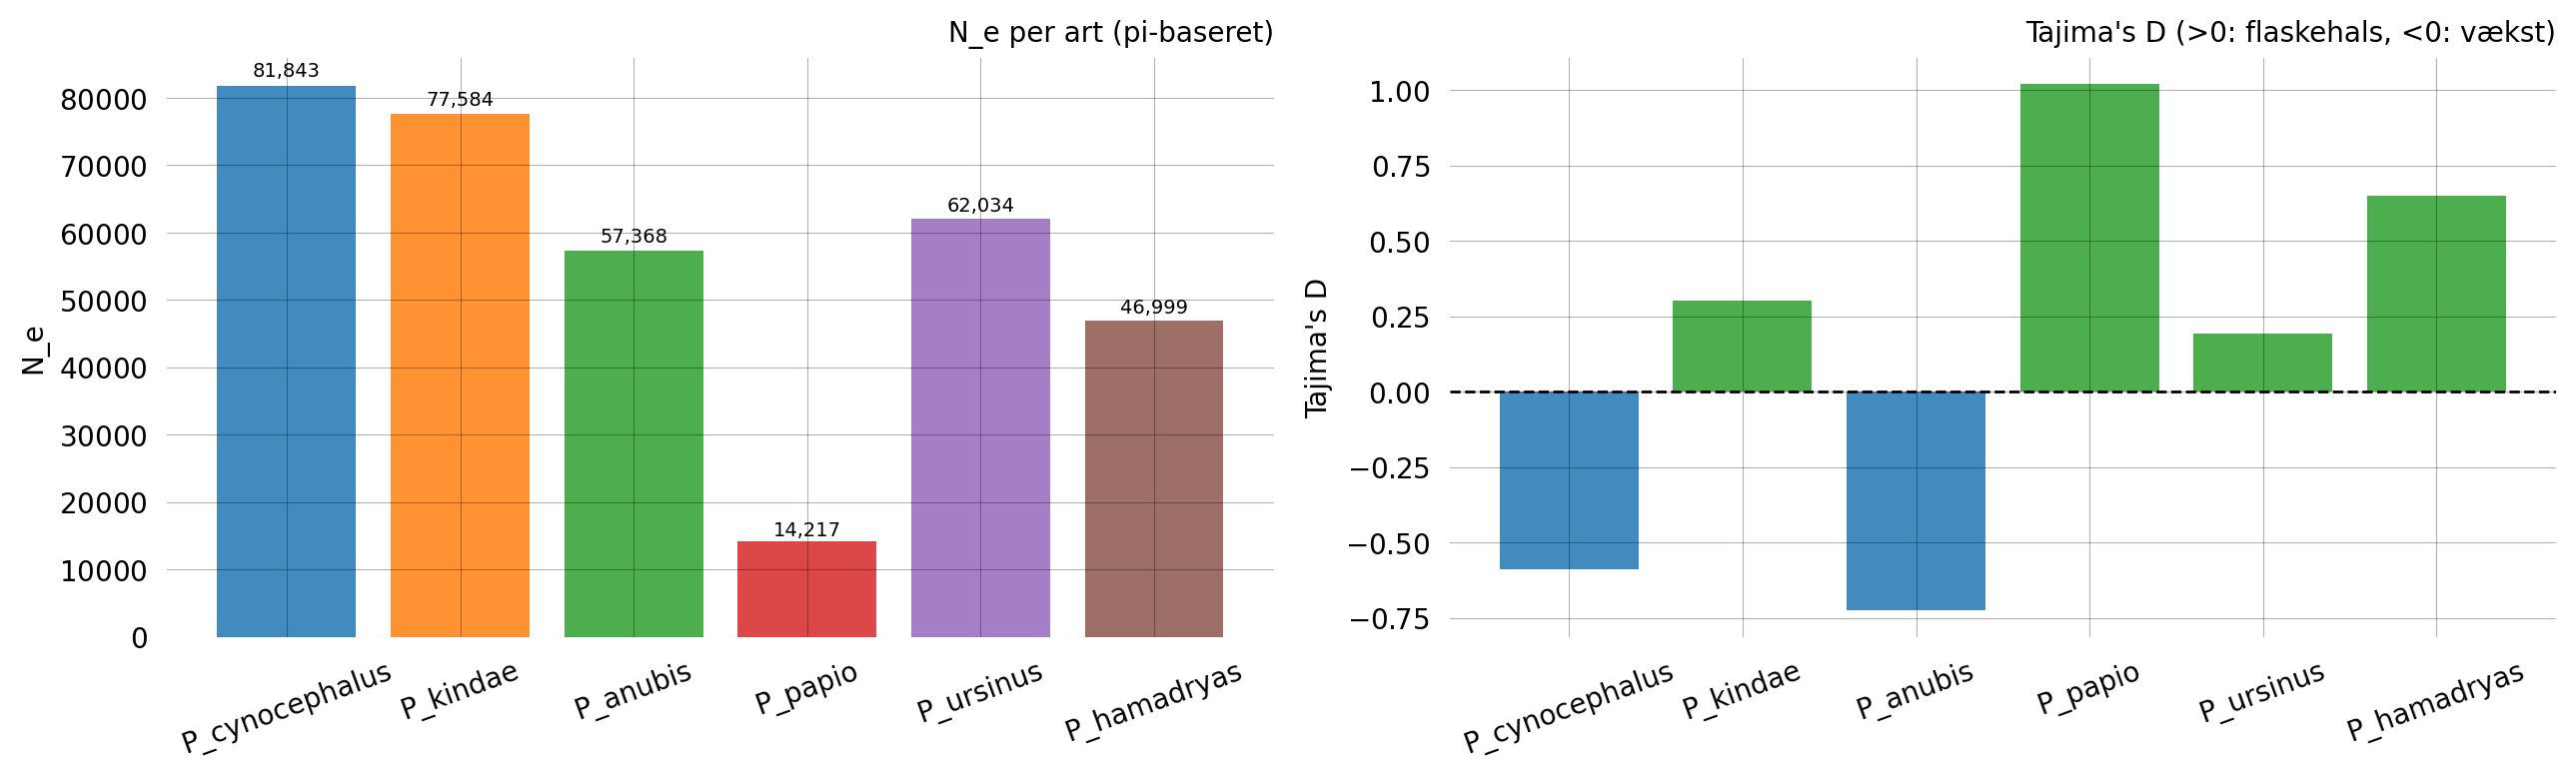


Fortolkning af Tajima's D:
  P_cynocephalus        : D=-0.589  => vækst/selektion
  P_kindae              : D= 0.301  => neutral
  P_anubis              : D=-0.725  => vækst/selektion
  P_papio               : D= 1.019  => flaskehals/admixture
  P_ursinus             : D= 0.192  => neutral
  P_hamadryas           : D= 0.649  => flaskehals/admixture


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

names = [r['Population'] for r in rows_pop]
Ne_v  = [r['N_ref'] for r in rows_pop]
D_v   = [r['Tajimas_D'] if not pd.isna(r['Tajimas_D']) else 0 for r in rows_pop]

axes[0].bar(names, Ne_v, color=[f'C{i}' for i in range(len(names))], alpha=0.85)
for bar, val in zip(axes[0].patches, Ne_v):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                 f'{val:,.0f}', ha='center', va='bottom', fontsize=7)
axes[0].set_ylabel('N_e'); axes[0].set_title('N_e per art (pi-baseret)')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(names, D_v, color=['C2' if d>0 else 'C0' for d in D_v], alpha=0.85)
axes[1].axhline(0, color='k', linestyle='--', lw=1)
axes[1].set_ylabel("Tajima's D")
axes[1].set_title("Tajima's D (>0: flaskehals, <0: vækst)")
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

# Fortolkning
print("\nFortolkning af Tajima's D:")
for r in rows_pop:
    D = r['Tajimas_D']
    if pd.isna(D): continue
    txt = "flaskehals/admixture" if D > 0.5 else "vækst/selektion" if D < -0.5 else "neutral"
    print(f"  {r['Population']:<22}: D={D:>6.3f}  => {txt}")

## SFS: Foldet og ufoldet med fuld n

Fra NB01: Singleton-andelen falder med $n$. Jeg bruger fuld $n$ per art til foldet SFS og subsampler til n_min for sammenligning på tværs af arter.

In [18]:
def folded_sfs(df, n_sub=None, n_obs=10_000, seed=42):
    if n_sub is None: n_sub = int(df['nr_samples'].max())
    rng = np.random.default_rng(seed)
    sfs = np.zeros(n_sub // 2)
    der = df['derived_count'].values.astype(int)
    tot = df['nr_samples'].values.astype(int)
    for idx in rng.integers(0, len(df), n_obs):
        n, ac = tot[idx], der[idx]
        if n < n_sub: continue
        k = min(rng.hypergeometric(ac, n-ac, n_sub), n_sub - rng.hypergeometric(ac, n-ac, n_sub))
        if 0 < k <= n_sub//2: sfs[k-1] += 1
    s = sfs.sum(); return sfs/s if s>0 else sfs

def unfolded_sfs(df, n_sub=None, n_obs=10_000, seed=42):
    if n_sub is None: n_sub = int(df['nr_samples'].max())
    rng = np.random.default_rng(seed)
    sfs = np.zeros(n_sub - 1)
    der = df['derived_count'].values.astype(int)
    tot = df['nr_samples'].values.astype(int)
    count = 0
    for idx in rng.integers(0, len(df), n_obs*10):
        if count >= n_obs: break
        n, ac = tot[idx], der[idx]
        if n < n_sub: continue
        k = rng.hypergeometric(ac, n-ac, n_sub)
        if 0 < k < n_sub: sfs[k-1] += 1; count += 1
    s = sfs.sum(); return sfs/s if s>0 else sfs

sfs_folded_full = {n: folded_sfs(df) for n, df in populations.items()}
sfs_unfolded_full = {n: unfolded_sfs(df) for n, df in populations.items()}
sfs_unfolded_min  = {n: unfolded_sfs(df, n_sub=n_min) for n, df in populations.items()}

for name in populations:
    n_full = int(populations[name]['nr_samples'].max())
    print(f"{name:<22}: {len(sfs_folded_full[name])} foldet bins (n_fuld={n_full}), "
          f"{len(sfs_unfolded_min[name])} ufoldet bins (n_min={n_min})")

P_cynocephalus        : 60 foldet bins (n_fuld=120), 7 ufoldet bins (n_min=8)
P_kindae              : 25 foldet bins (n_fuld=50), 7 ufoldet bins (n_min=8)
P_anubis              : 87 foldet bins (n_fuld=174), 7 ufoldet bins (n_min=8)
P_papio               : 12 foldet bins (n_fuld=24), 7 ufoldet bins (n_min=8)
P_ursinus             : 4 foldet bins (n_fuld=8), 7 ufoldet bins (n_min=8)
P_hamadryas           : 24 foldet bins (n_fuld=48), 7 ufoldet bins (n_min=8)


In [19]:
sfs_folded_full = {}
for name, df in populations.items():
    sfs_folded_full[name] = folded_sfs(df)
    print(f"{name:<22}: SFS = {np.round(sfs_folded_full[name], 4)}")

sfs_unfolded_full = {}
for name, df in populations.items():
    sfs_unfolded_full[name] = unfolded_sfs(df, n_obs=10_000)
    print(f"{name:<22}: {np.round(sfs_unfolded_full[name], 4)}")

P_cynocephalus        : SFS = [0.2095 0.1234 0.0844 0.0603 0.0446 0.0326 0.0321 0.0261 0.0233 0.0189
 0.0178 0.0165 0.0142 0.0134 0.0121 0.012  0.0119 0.0094 0.0094 0.0093
 0.0079 0.0082 0.0068 0.0087 0.0068 0.0073 0.0069 0.0076 0.0061 0.0059
 0.0053 0.0062 0.0061 0.0056 0.0059 0.0052 0.006  0.0056 0.0048 0.0053
 0.0033 0.0062 0.0051 0.0055 0.005  0.0045 0.0049 0.0043 0.0044 0.0044
 0.0046 0.0041 0.0048 0.005  0.0045 0.0053 0.0037 0.0037 0.0045 0.0028]
P_kindae              : SFS = [0.1668 0.0996 0.0822 0.071  0.0608 0.0462 0.0435 0.0416 0.0374 0.0305
 0.0295 0.0299 0.0249 0.0235 0.0222 0.0206 0.0228 0.0215 0.019  0.0202
 0.0176 0.0206 0.0186 0.0165 0.013 ]
P_anubis              : SFS = [0.1946 0.1179 0.0784 0.0531 0.0459 0.0382 0.0296 0.0245 0.0205 0.0188
 0.0152 0.0167 0.0137 0.0124 0.0117 0.0132 0.0098 0.0101 0.0091 0.0074
 0.008  0.0071 0.008  0.0063 0.0088 0.0071 0.0069 0.0061 0.0053 0.0054
 0.0056 0.0052 0.0054 0.0057 0.0037 0.004  0.0052 0.0052 0.0055 0.0039
 0.0038 0.0037 0.003

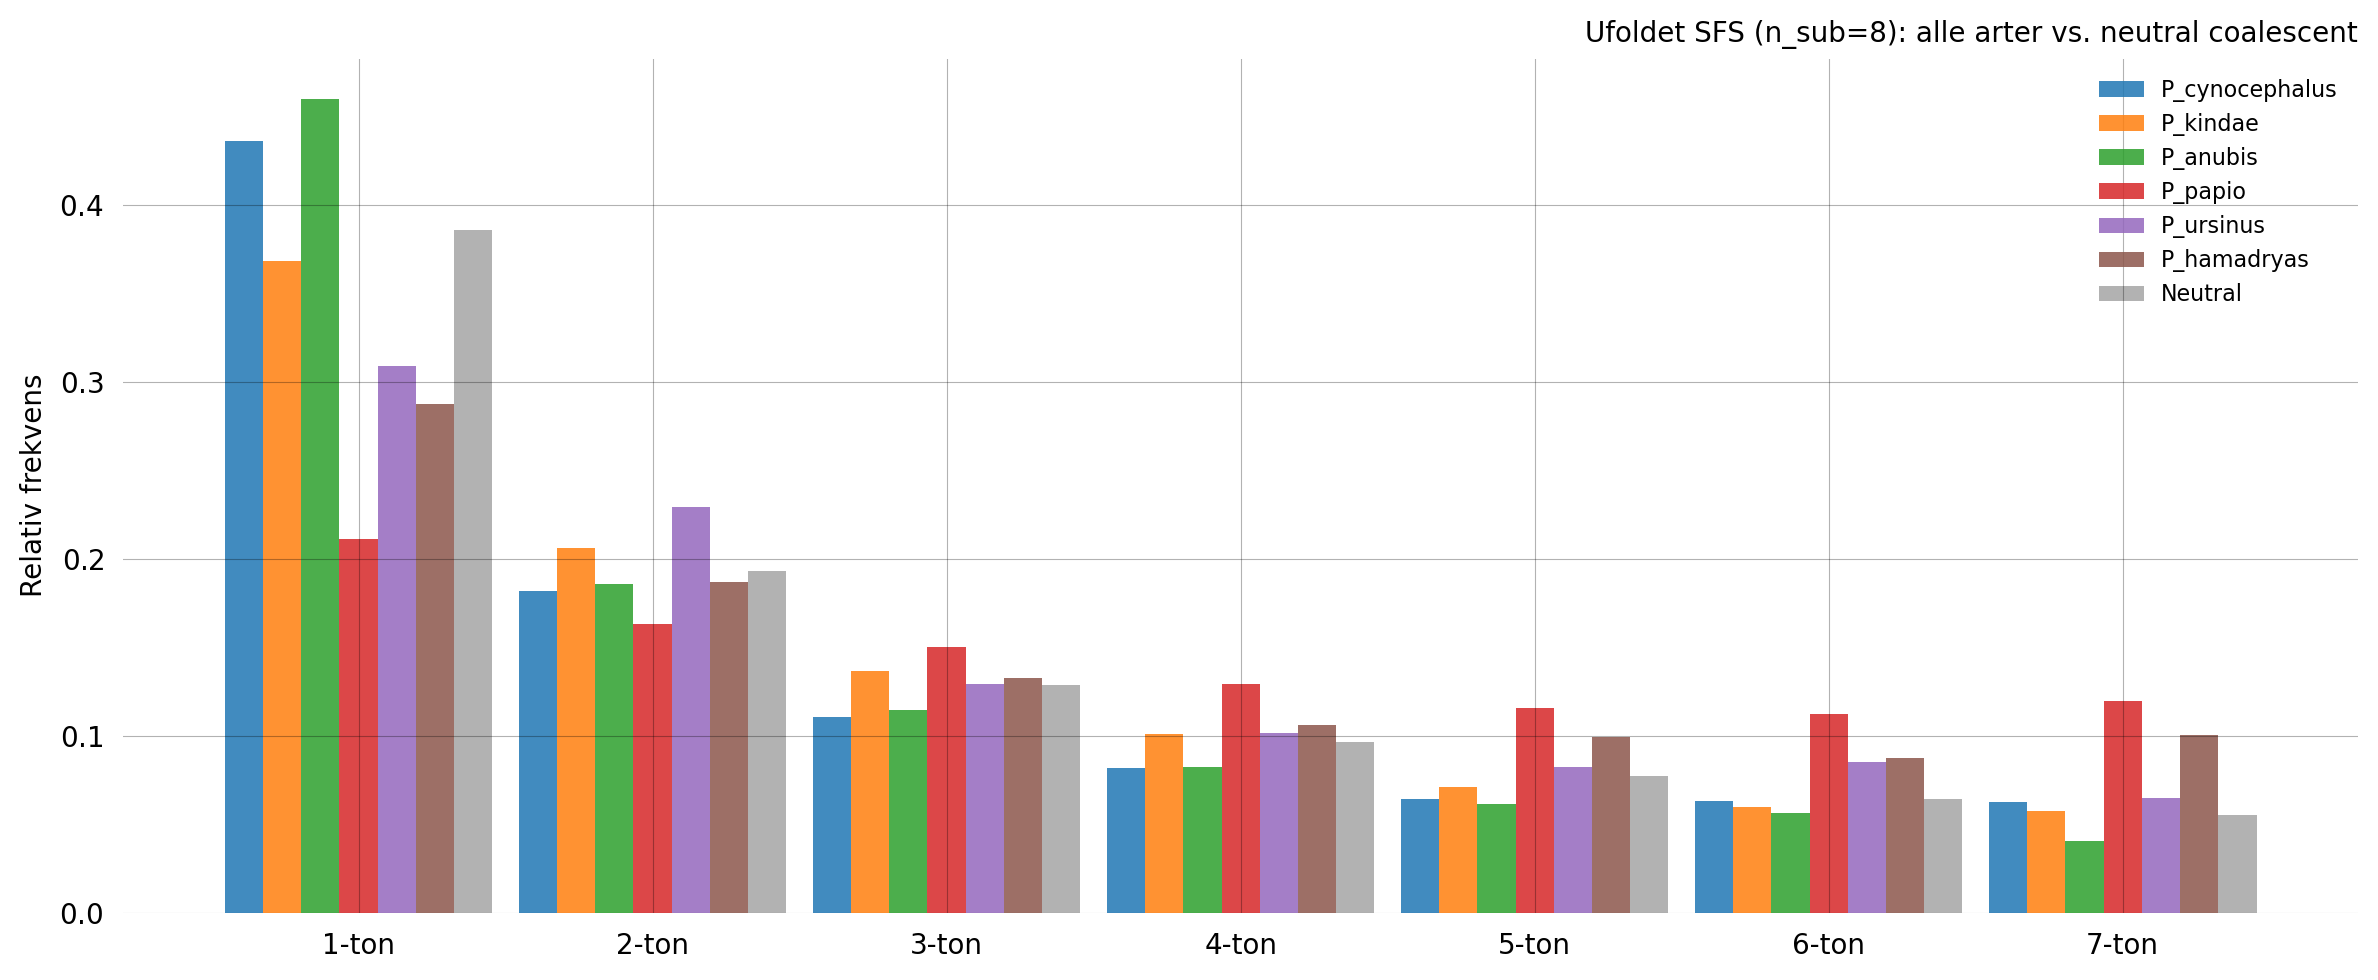

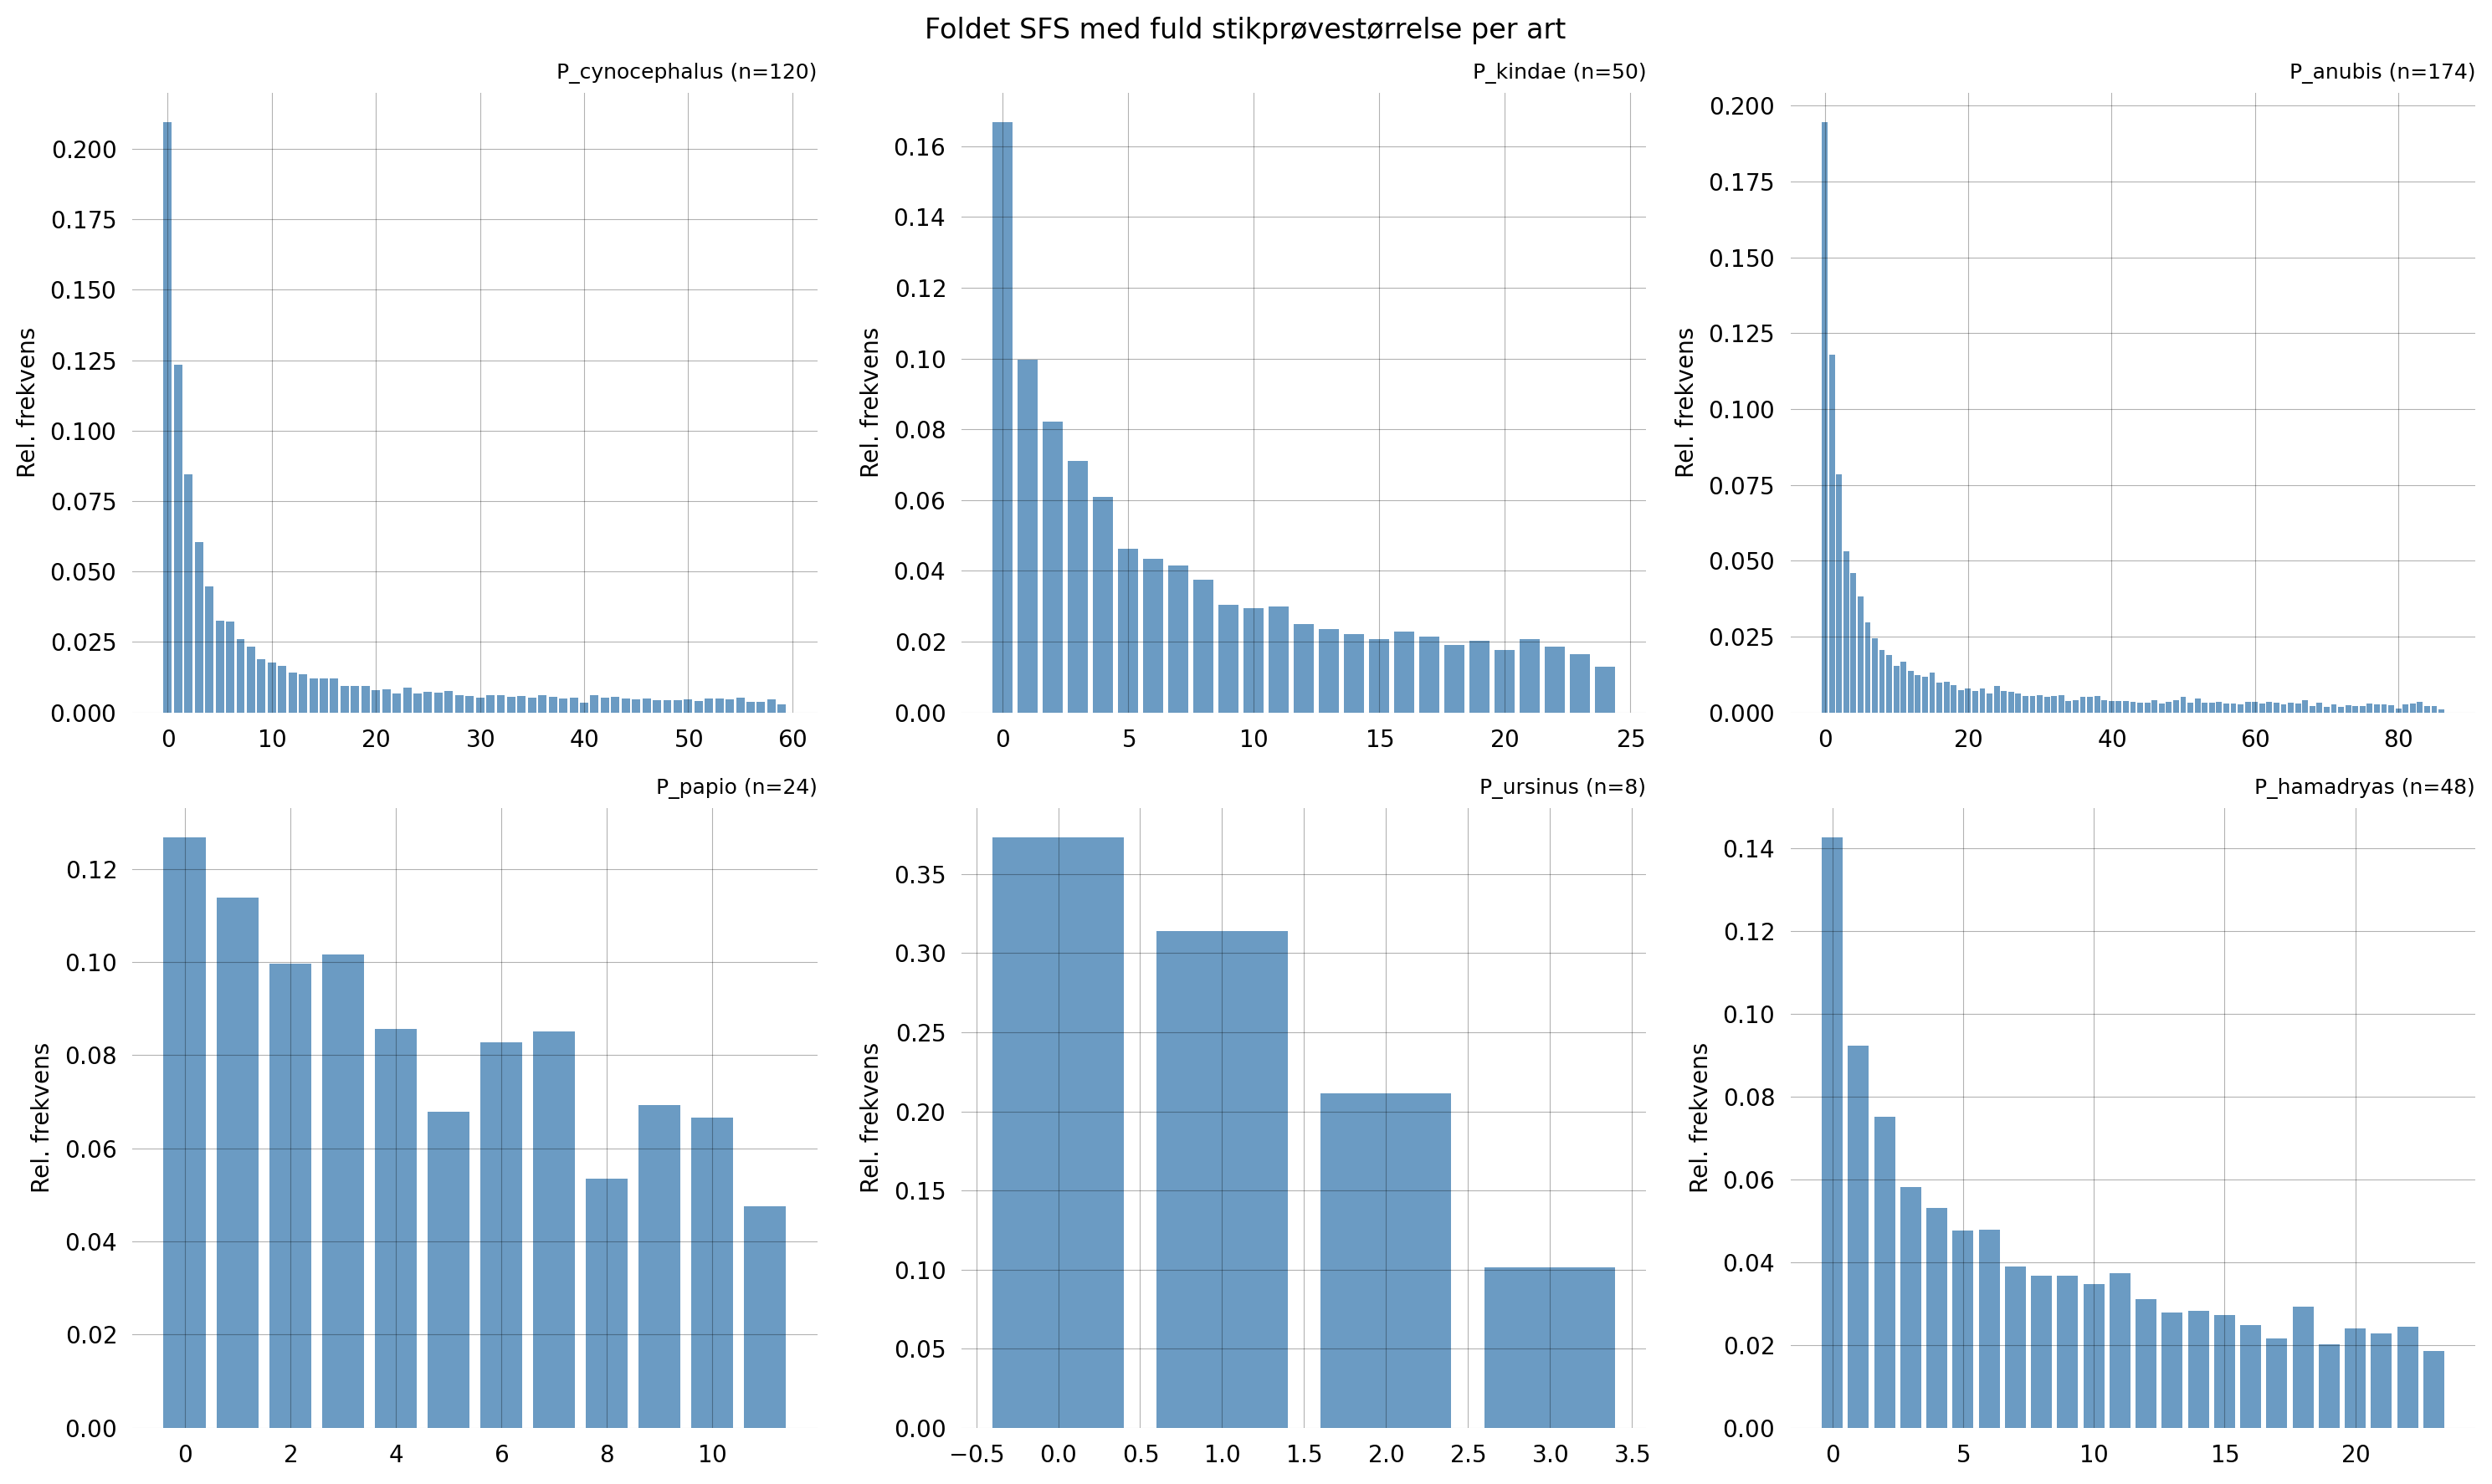

In [20]:
# Ufoldet SFS: alle arter subsampled til n_min til direkte sammenligning
x = np.arange(n_min - 1); w = 0.13
fig, ax = plt.subplots(figsize=(12, 5))
for idx, (name, sfs) in enumerate(sfs_unfolded_min.items()):
    ax.bar(x + idx*w, sfs, w, label=name, alpha=0.85)
a_n = sum(1/k for k in range(1, n_min))
neutral = [1/(k+1)/a_n for k in range(n_min-1)]
ax.bar(x + len(sfs_unfolded_min)*w, neutral, w, label='Neutral', color='k', alpha=0.3)
ax.set_xticks(x + w*3); ax.set_xticklabels([f"{i+1}-ton" for i in range(n_min-1)])
ax.set_ylabel('Relativ frekvens')
ax.set_title(f'Ufoldet SFS (n_sub={n_min}): alle arter vs. neutral coalescent')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

# Foldet SFS med fuld n per art
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (name, sfs) in zip(axes.flat, sfs_folded_full.items()):
    n_full = int(populations[name]['nr_samples'].max())
    ax.bar(range(len(sfs)), sfs, color='steelblue', alpha=0.8)
    ax.set_title(f'{name} (n={n_full})', fontsize=9)
    ax.set_ylabel('Rel. frekvens')
plt.suptitle('Foldet SFS med fuld stikprøvestørrelse per art', fontsize=12)
plt.tight_layout(); plt.show()

## SVGD-inferens af theta per population

Fra NB02:

- Adam(0.25): lavest std og bias for bavian-theta (3-20)
- n_particles=60, n_iterations=300: optimal fra NB04
- DataPrior baseret på MoM: bedste prior til bavian-data
- GaussPrior fallback ved DataPrior-kollaps (NB02)
- Fuld n per population: bedre informationsindhold end n=4 (NB01)
- plot_trace og analyze_trace til diagnostik (NB02)

In [21]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"   
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=1"

import time
import warnings
warnings.filterwarnings("ignore")

from phasic import (
    Graph, with_ipv, GaussPrior, HalfCauchyPrior,
    Adam, DataPrior, clear_caches, dense_to_sparse,
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sgkit as sg
from pathlib import Path

In [22]:
def build_coal_graph(n):
    @with_ipv([n] + [0]*(n-1))
    def coal(state):
        T = []
        for i in range(state.size):
            for j in range(i, state.size):
                same = int(i == j)
                if same and state[i] < 2: continue
                if not same and (state[i]<1 or state[j]<1): continue
                new = state.copy(); new[i]-=1; new[j]-=1; new[i+j+1]+=1
                T.append((new, [state[i]*(state[j]-same)/(1+same)]))
        return T
    return Graph(coal)

def allele_counts_to_sfs_obs(df, n_sub=8, n_obs=5000, seed=42):
    rng = np.random.default_rng(seed)
    der = df['derived_count'].values.astype(int)
    tot = df['nr_samples'].values.astype(int)
    obs = []
    indices = rng.integers(0, len(df), n_obs * 20)
    for idx in indices:
        if len(obs) >= n_obs:
            break
        n, ac = tot[idx], der[idx]
        if n < n_sub:
            continue
        k = rng.hypergeometric(ac, n - ac, n_sub)
        if 0 < k < n_sub:
            obs.append(float(k))
    return np.array(obs[:n_obs])


In [23]:
#| label: tbl-svgd-resultater
#| tbl-cap: "SVGD-estimater af Ne per bavianpopulation."

import time
N_SUB = 8
N_PARTICLES = 60
N_ITER = 300


svgd_results = {}

for name, df in populations.items():
    n_full  = int(df['nr_samples'].max())
    Ne_pi   = N_ref_dict[name]
    theta_start = 4 * Ne_pi * MU
    t0 = time.perf_counter()
    g  = build_coal_graph(N_SUB)
    data = allele_counts_to_sfs_obs(df, n_sub=N_SUB, n_obs=5000)
    rewards = g.states().T[:-1]  
    g.update_weights([theta_start])
    try:
        prior = DataPrior(g, data)
    except Exception:
        prior = GaussPrior(ci=[theta_start * 0.1, theta_start * 10])

    # Brug reward-baseret SVGD med SFS-observationer
    sparse_data = dense_to_sparse(
        np.column_stack([
            np.where(data == k+1, data, np.nan)
            for k in range(N_SUB - 1)
        ])
    )

    sv = g.svgd(
        sparse_data,
        rewards=rewards,
        prior=prior,
        optimizer=OPTIMIZER,
        n_particles=N_PARTICLES,
        n_iterations=N_ITER,
        return_history=True,
    )

    res = sv.get_results()
    th  = res['theta_mean'].item()
    std = res['theta_std'].item()

    # Konverter til Ne: theta = 4 * Ne * mu => Ne = theta / (4 * mu)
    Ne      = th  / (4 * MU) if th  > 0 else np.nan
    Ne_low  = (th - 1.96 * std) / (4 * MU) if (th - 1.96 * std) > 0 else np.nan
    Ne_hi   = (th + 1.96 * std) / (4 * MU) if (th + 1.96 * std) > 0 else np.nan

    E_H_coal = 2 * (1 - 1/N_SUB)
    E_H_yr   = E_H_coal * 2 * Ne * GEN if Ne > 0 else np.nan

    svgd_results[name] = {
        'theta': th, 'std': std,
        'Ne': Ne, 'Ne_low': Ne_low, 'Ne_hi': Ne_hi,
        'E_H_yr': E_H_yr,
        'n_hap': n_full, 'n_sub': N_SUB, 'sv': sv,
    }

    print(f"{name:<22} n_full={n_full} n_sub={N_SUB}: "
          f"theta={th:.6f}+/-{std:.6f}  "
          f"Ne {Ne:,.0f}  "
          f"95 procent-CI [{Ne_low:,.0f} – {Ne_hi:,.0f}]  "
          f"E[TMRCA]~{E_H_yr/1e6:.2f} Myr  "
          f"({time.perf_counter()-t0:.1f}s)")

# Resultattabel
rows = []
for name, res in svgd_results.items():
    rows.append({
        'Population':    name,
        'n_haplotyper':  res['n_hap'],
        'theta':         round(res['theta'], 8),
        'std':           round(res['std'], 8),
        'Ne (est.)':     round(res['Ne'])     if not np.isnan(res['Ne'])     else np.nan,
        'Ne 95 procent lav':    round(res['Ne_low']) if not np.isnan(res['Ne_low']) else np.nan,
        'Ne 95 procent høj':    round(res['Ne_hi'])  if not np.isnan(res['Ne_hi'])  else np.nan,
        'E[TMRCA]': round(res['E_H_yr']/1e6, 2) if not np.isnan(res['E_H_yr']) else np.nan,
    })

df_results = pd.DataFrame(rows)
print()
print(df_results.to_string(index=False))

P_hamadryas            n_full=48 n_sub=8: theta=0.552865+/-0.011389  Ne 15,357,360  95 procent-CI [14,737,319 – 15,977,401]  E[TMRCA]~591.26 Myr  (271.7s)

    Population  n_haplotyper    theta      std  Ne (est.)  Ne 95 procent lav  Ne 95 procent høj  E[TMRCA]
P_cynocephalus           120 0.771338 0.016529   21426046           20526123           22325968    824.90
      P_kindae            50 0.710471 0.014389   19735319           18951899           20518739    759.81
      P_anubis           174 0.845590 0.017650   23488609           22527689           24449529    904.31
       P_papio            24 0.456060 0.014503   12668337           11878712           13457962    487.73
     P_ursinus             8 0.628257 0.010995   17451587           16852962           18050212    671.89
   P_hamadryas            48 0.552865 0.011389   15357360           14737319           15977401    591.26


In [24]:
# Kovariansmatrix for SFS-komponenter per population
# Viser om singleton og doubleton er negativt korrelerede
for name, r in svgd_results.items():
    g_cov = build_coal_graph(4)
    g_cov.update_weights([r['theta']])
    reward_mat = g_cov.states().T
    
    cov_matrix = np.zeros((3, 3))
    for i in range(3):
        for j in range(3):
            ri = reward_mat[i]; rj = reward_mat[j]
            Eij = g_cov.expectation(ri * rj)  # joint moment
            Ei  = g_cov.expectation(ri)
            Ej  = g_cov.expectation(rj)
            cov_matrix[i,j] = Eij - Ei*Ej
    
    print(f"{name}:")
    print(pd.DataFrame(cov_matrix,
          index=['1-ton','2-ton','3-ton'],
          columns=['1-ton','2-ton','3-ton']).round(4))
    print()

P_cynocephalus:
        1-ton   2-ton   3-ton
1-ton -0.6730 -2.4973 -1.3767
2-ton -2.4973  0.4800 -1.1205
3-ton -1.3767 -1.1205  0.1173

P_kindae:
        1-ton   2-ton   3-ton
1-ton -1.3560 -3.0239 -1.7031
2-ton -3.0239  0.3648 -1.3207
3-ton -1.7031 -1.3207  0.0579

P_anubis:
        1-ton   2-ton   3-ton
1-ton -0.0754 -2.0087 -1.0763
2-ton -2.0087  0.5725 -0.9324
3-ton -1.0763 -0.9324  0.1668

P_papio:
        1-ton   2-ton   3-ton
1-ton -8.9990 -8.1540 -4.9487
2-ton -8.1540 -1.1534 -3.2053
3-ton -4.9487 -3.2053 -0.6751

P_ursinus:
        1-ton   2-ton   3-ton
1-ton -2.7061 -4.0059 -2.3169
2-ton -4.0059  0.1193 -1.6890
3-ton -2.3169 -1.6890 -0.0649

P_hamadryas:
        1-ton   2-ton   3-ton
1-ton -4.6456 -5.3374 -3.1563
2-ton -5.3374 -0.2570 -2.1811
3-ton -3.1563 -2.1811 -0.2482



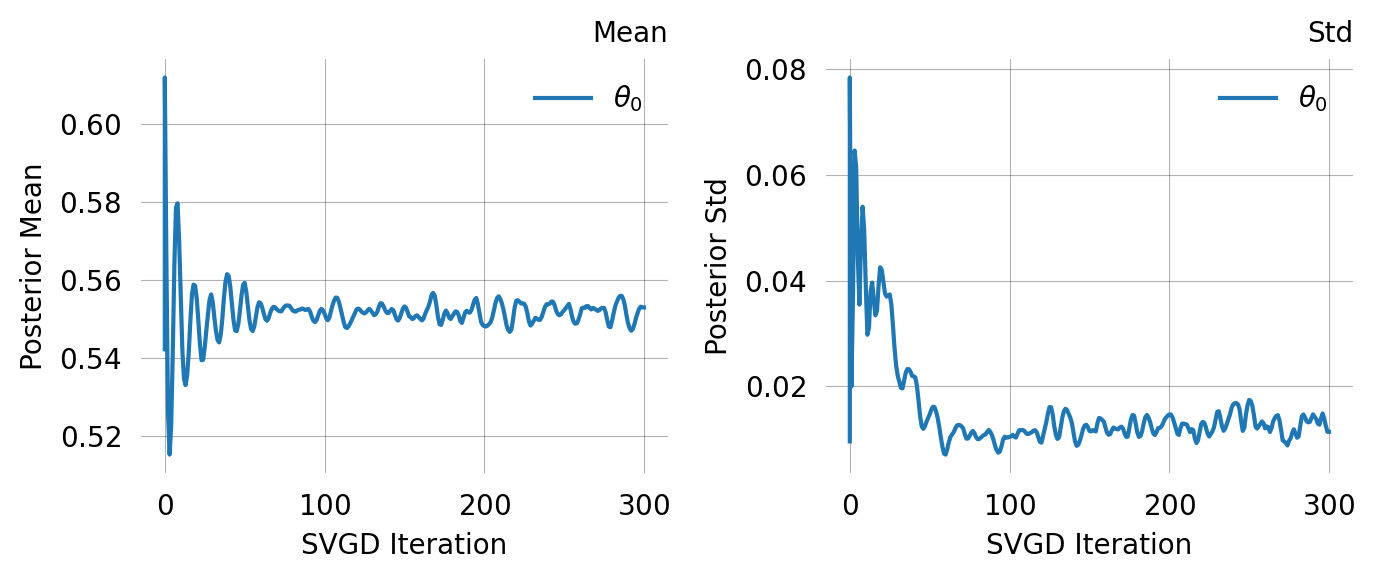

In [25]:
sv.plot_convergence()

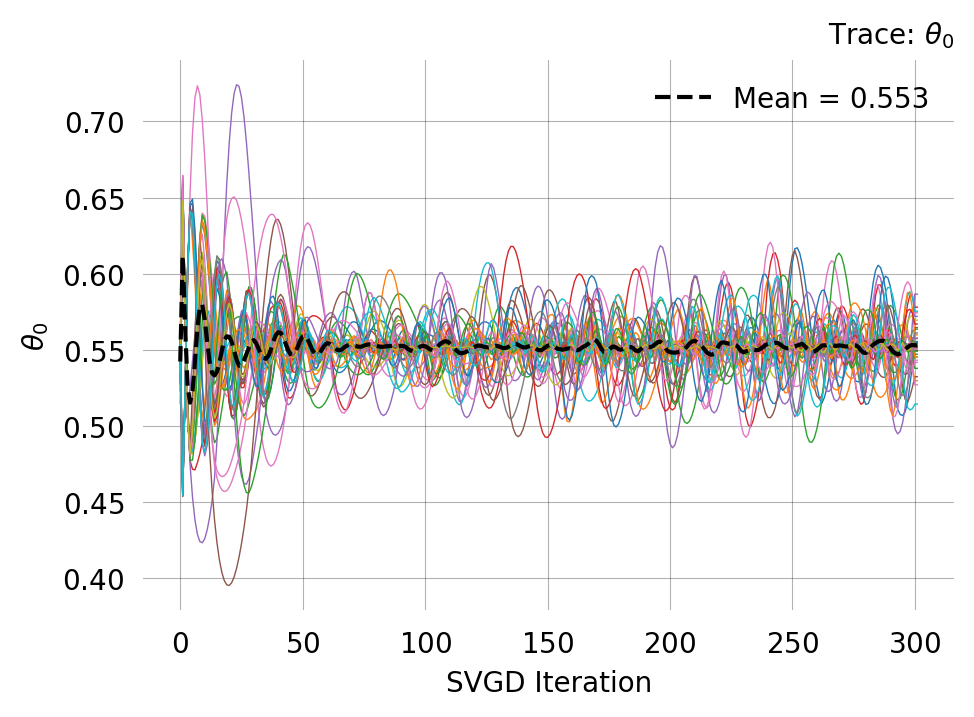

In [26]:
sv.plot_trace()

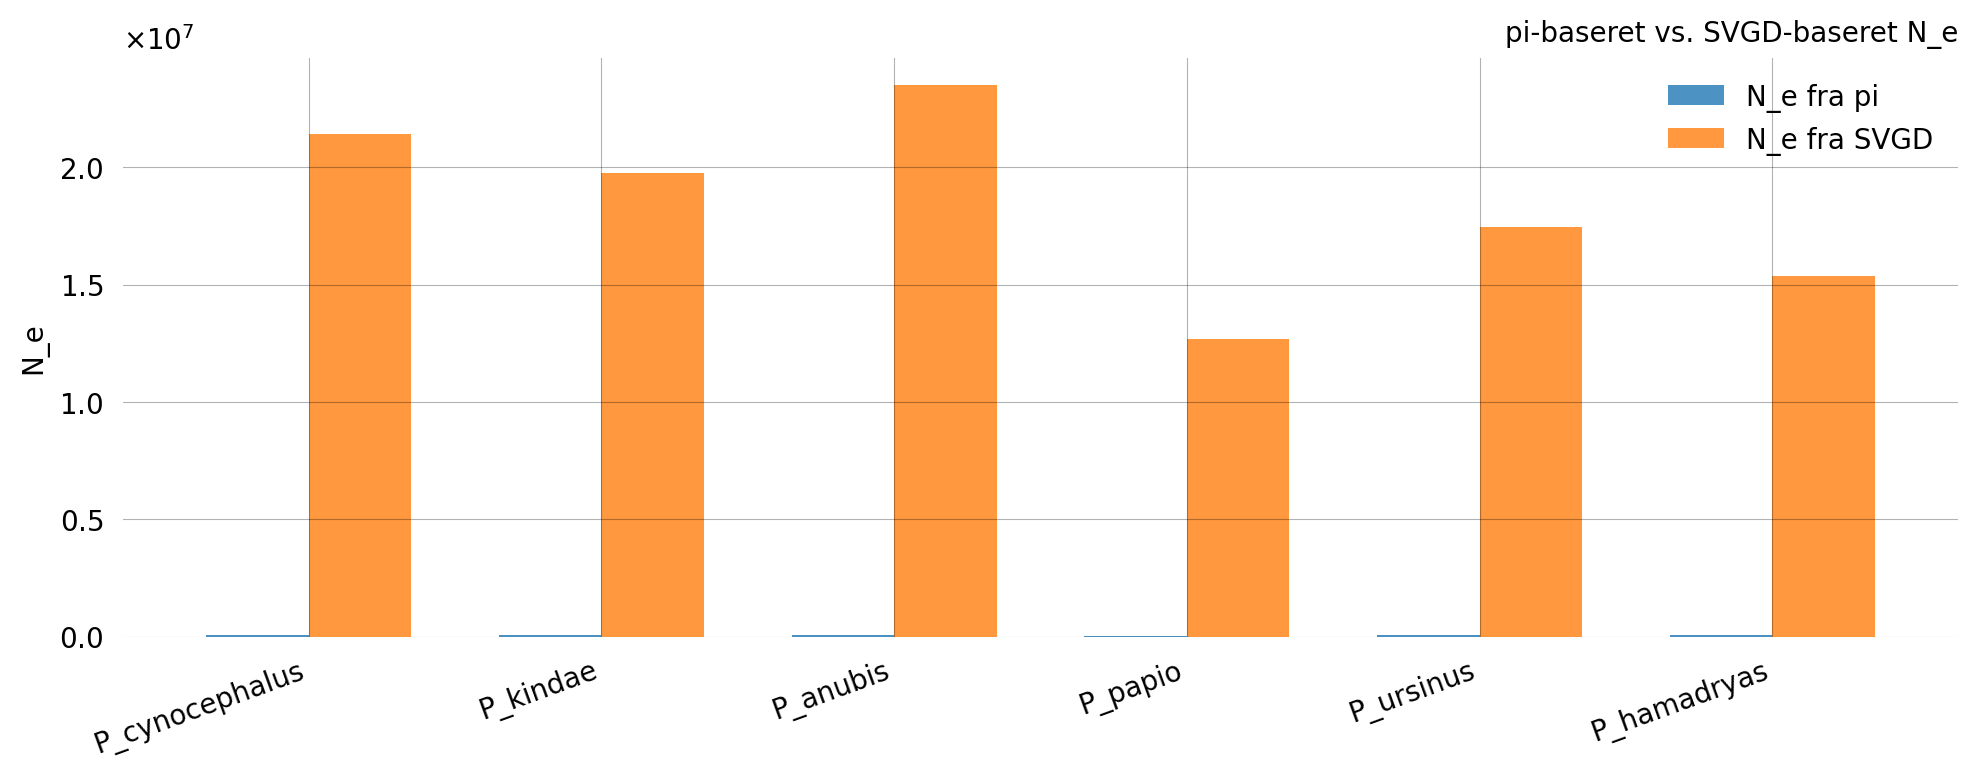

In [27]:
# N_e: pi-baseret vs. SVGD
fig, ax = plt.subplots(figsize=(10, 4))
names_plt = list(svgd_results.keys())
Ne_pi   = [N_ref_dict[n] for n in names_plt]
Ne_svgd = [svgd_results[n]['Ne'] for n in names_plt]
x = np.arange(len(names_plt)); w = 0.35
ax.bar(x-w/2, Ne_pi,   w, label='N_e fra pi', color='C0', alpha=0.8)
ax.bar(x+w/2, Ne_svgd, w, label='N_e fra SVGD', color='C1', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(names_plt, rotation=20, ha='right')
ax.set_ylabel('N_e'); ax.set_title('pi-baseret vs. SVGD-baseret N_e')
ax.legend(); plt.tight_layout(); plt.show()

In [28]:
# Sojourn times
print("Forventede sojourn times per population (n_sub=8)")
print(f"{'Population':<22} {'k=8':>12} {'k=7':>12} {'k=6':>12} "
      f"{'k=5':>12} {'k=4':>12} {'k=3':>12} {'k=2':>12} "
      f"{'E[H] (år)':>14}")
print("-" * 130)

rows_sj = []
for name, r in svgd_results.items():
    Ne  = r['Ne']
    if np.isnan(Ne):
        continue
    sj_yr = {k: 2/(k*(k-1)) * 2 * Ne * GEN for k in [8,7,6,5,4,3,2]}
    E_H_yr = sum(sj_yr.values())

    print(f"{name:<22}  "
          + "  ".join(f"{sj_yr[k]:>12,.0f}" for k in [8,7,6,5,4,3,2])
          + f"  {E_H_yr:>14,.0f}")

    rows_sj.append({
        'Population':   name,
        **{f'sojourn_k{k}_yr': round(sj_yr[k]) for k in [8,7,6,5,4,3,2]},
        'E_H_yr':       round(E_H_yr),
        'Ne':           round(Ne),
    })

df_sj = pd.DataFrame(rows_sj)

Forventede sojourn times per population (n_sub=8)
Population                      k=8          k=7          k=6          k=5          k=4          k=3          k=2      E[H] (år)
----------------------------------------------------------------------------------------------------------------------------------
P_cynocephalus            16,834,750    22,446,333    31,424,867    47,137,300    78,562,167   157,124,334   471,373,003     824,902,755
P_kindae                  15,506,322    20,675,096    28,945,135    43,417,702    72,362,837   144,725,674   434,177,022     759,809,789
P_anubis                  18,455,336    24,607,114    34,449,960    51,674,940    86,124,899   172,249,798   516,749,395     904,311,442
P_papio                    9,953,693    13,271,591    18,580,227    27,870,341    46,450,568    92,901,137   278,703,410     487,730,967
P_ursinus                 13,711,961    18,282,615    25,595,661    38,393,491    63,989,152   127,978,304   383,934,913     671,886,097
P_ham

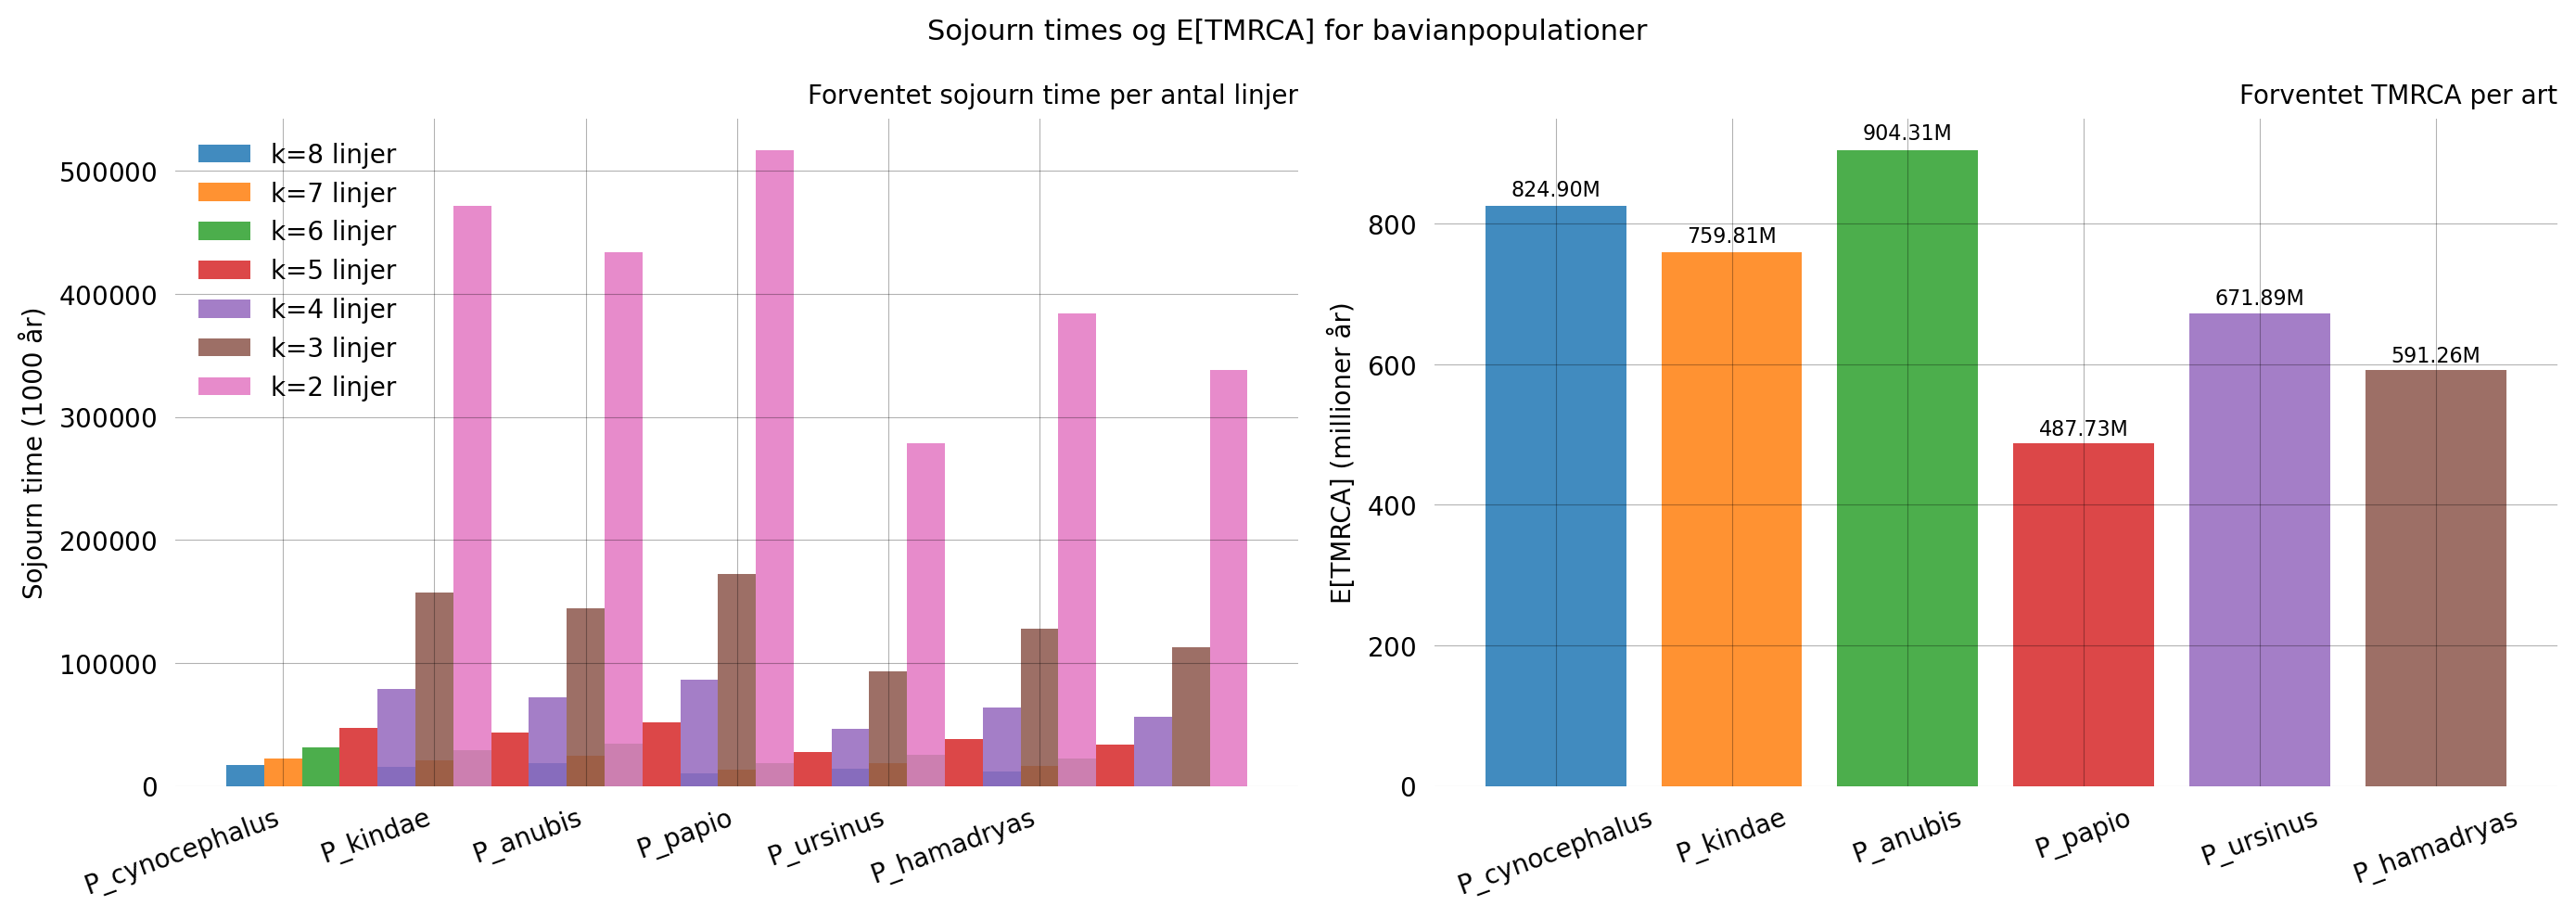

In [29]:
# Visualiser sojourn times
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pop_names_sj = df_sj['Population'].tolist()
x = np.arange(len(pop_names_sj))
w = 0.25

for ax_idx, (k, col) in enumerate(zip([8, 7, 6, 5, 4, 3, 2], ['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7'])):
    col_name = f'sojourn_k{k}_yr'
    axes[0].bar(x + (ax_idx-1)*w, df_sj[col_name]/1000, w,
                label=f'k={k} linjer', color=col, alpha=0.85)

axes[0].set_xticks(x)
axes[0].set_xticklabels(pop_names_sj, rotation=20, ha='right')
axes[0].set_ylabel('Sojourn time (1000 år)')
axes[0].set_title('Forventet sojourn time per antal linjer')
axes[0].legend()

# E[H] total i år
axes[1].bar(pop_names_sj, df_sj['E_H_yr']/1e6,
            color=[f'C{i}' for i in range(len(pop_names_sj))], alpha=0.85)
for bar, val in zip(axes[1].patches, df_sj['E_H_yr']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                 f'{val/1e6:.2f}M', ha='center', va='bottom', fontsize=8)
axes[1].set_ylabel('E[TMRCA] (millioner år)')
axes[1].set_title('Forventet TMRCA per art')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('Sojourn times og E[TMRCA] for bavianpopulationer', fontsize=11)
plt.tight_layout(); plt.show()

## Posterior Predictive Check (PPC)

Fra NB02: PPC via ECDF sammenligning verificerer modelfit.

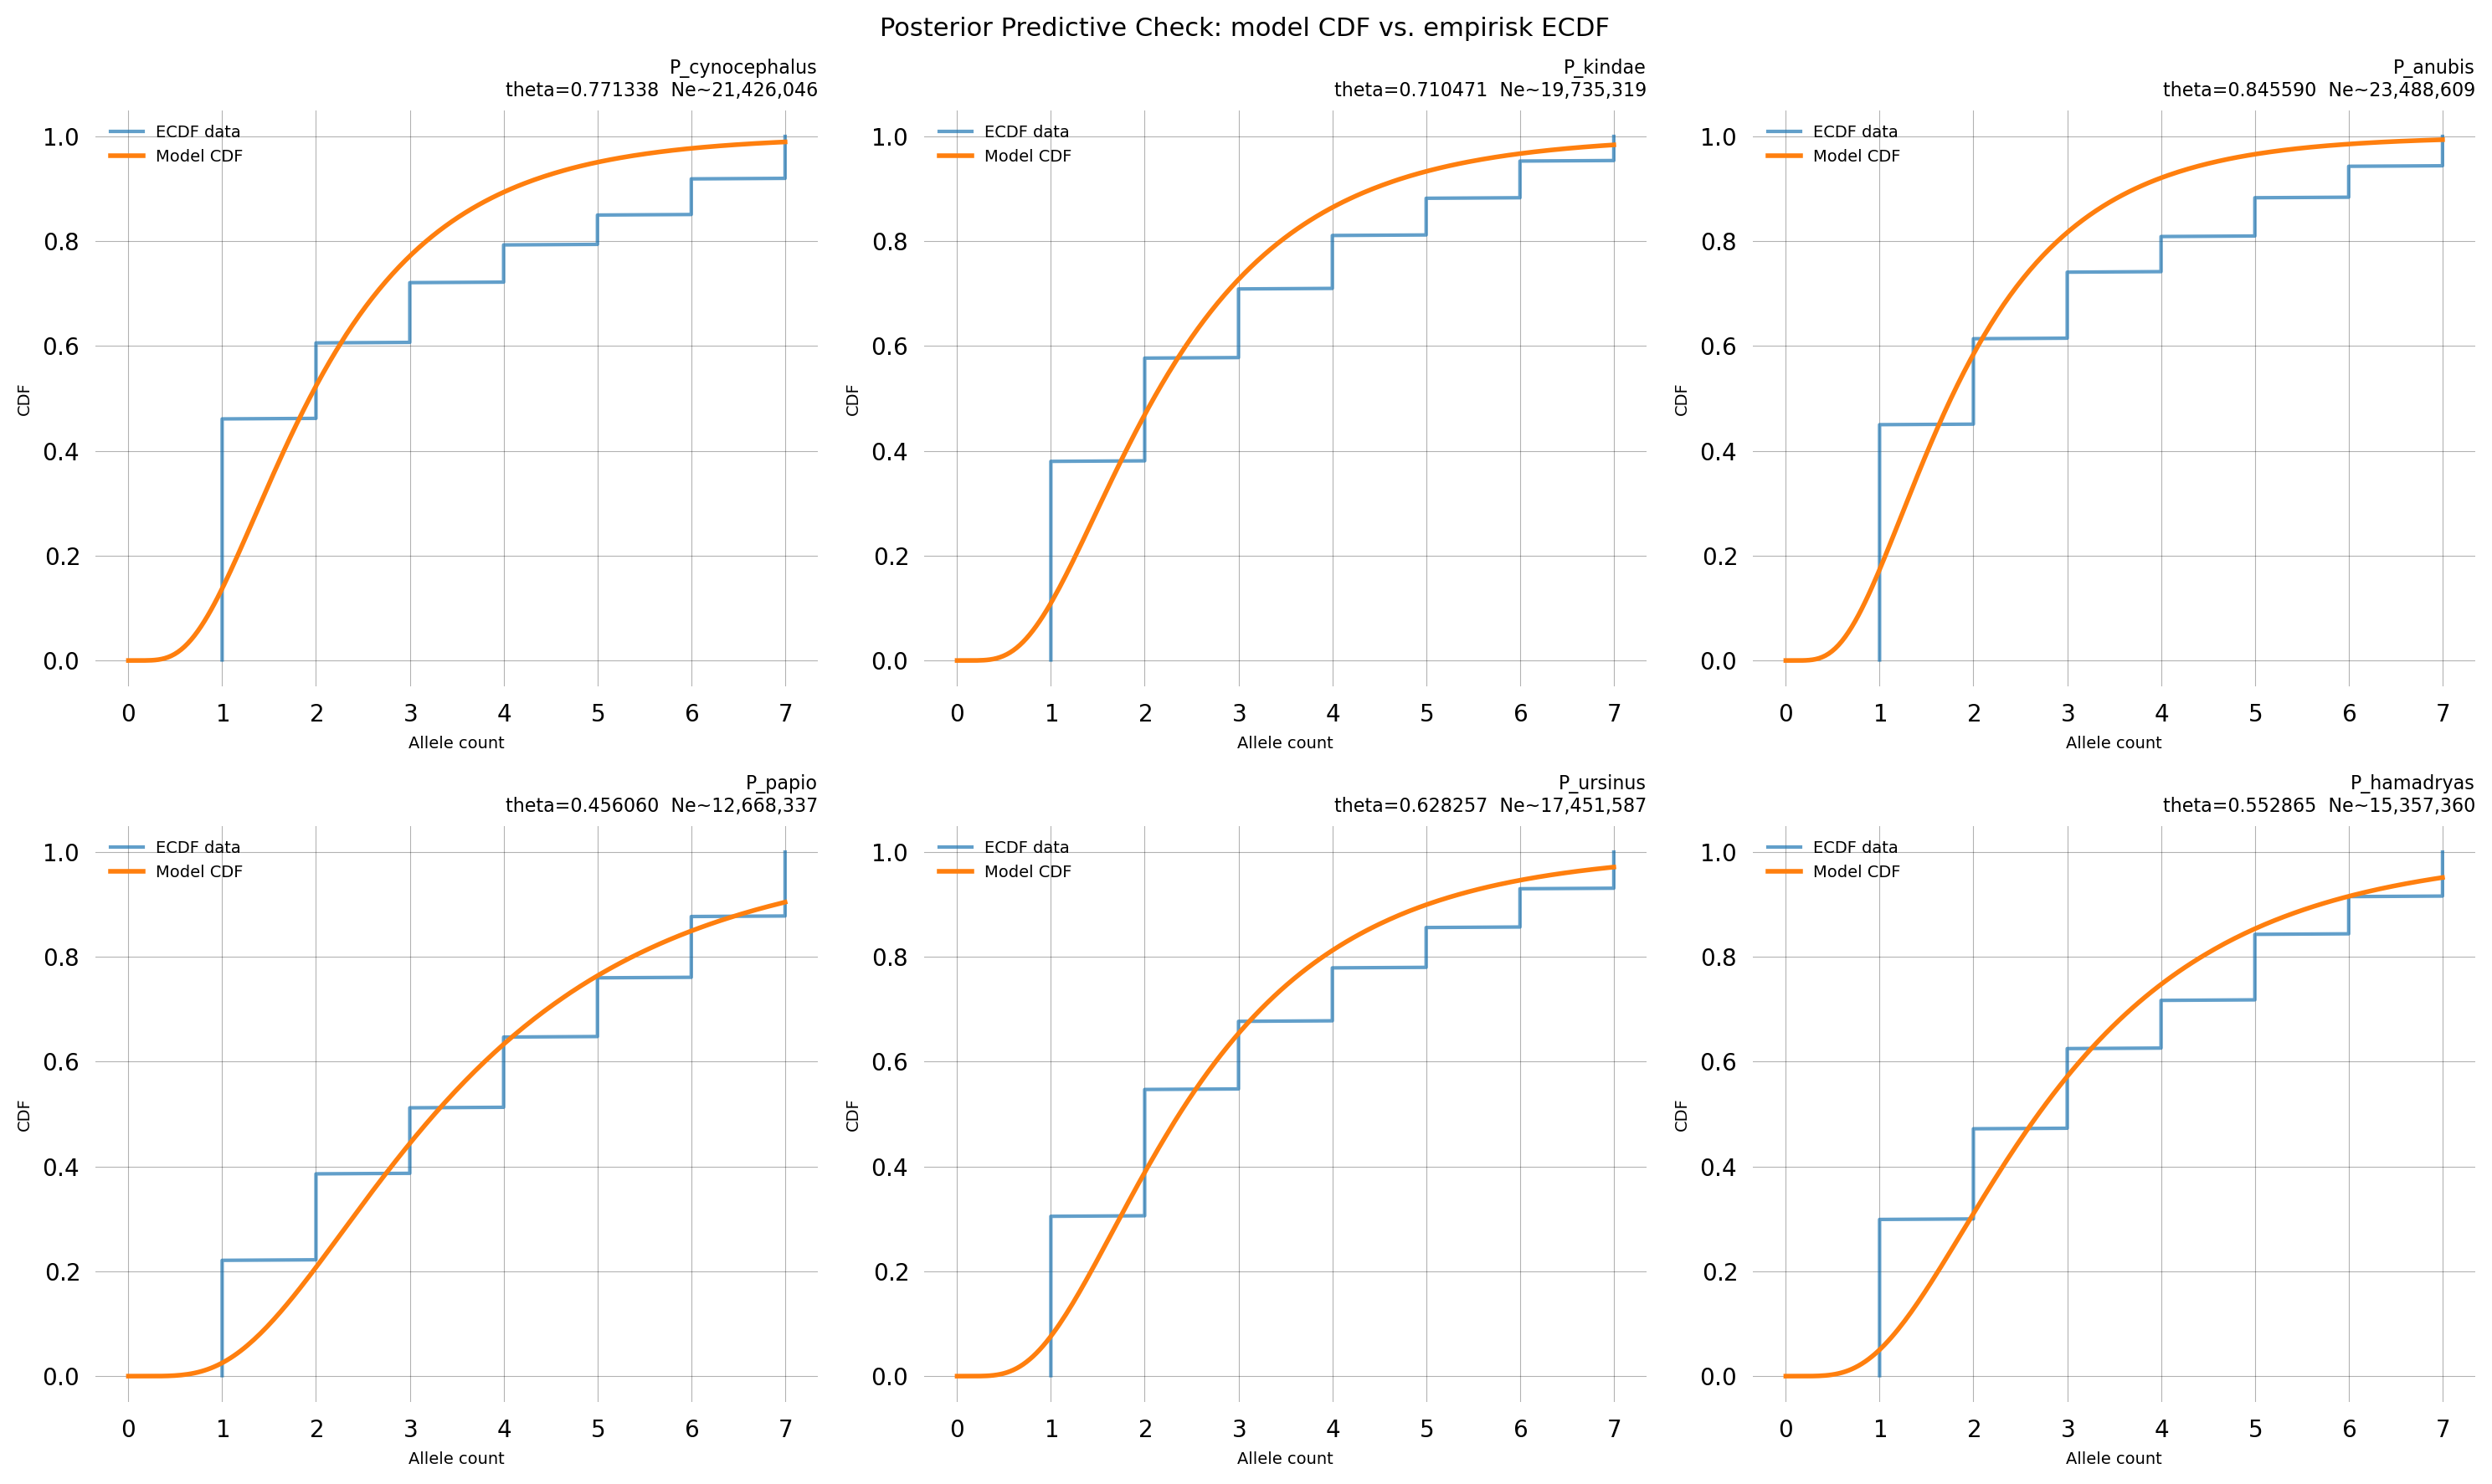

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (name, r) in zip(axes.flat, svgd_results.items()):
    g = build_coal_graph(N_SUB)
    g.update_weights([r['theta']])
    data_ppc = allele_counts_to_sfs_obs(
        populations[name], n_sub=N_SUB, n_obs=1000
    )

    t_max = np.percentile(data_ppc, 99)
    tv = np.linspace(0.001, t_max, 200)

    ax.plot(
        np.sort(data_ppc),
        np.arange(1, len(data_ppc)+1) / len(data_ppc),
        'C0-', lw=1.5, alpha=0.7, label='ECDF data',
    )
    ax.plot(tv, g.cdf(tv), 'C1-', lw=2, label='Model CDF')

    Ne_ppc = r['theta'] / (4 * MU) if r['theta'] > 0 else np.nan
    title  = f"{name}\ntheta={r['theta']:.6f}  Ne~{Ne_ppc:,.0f}"
    ax.set_title(title, fontsize=8)
    ax.set_xlabel('Allele count', fontsize=7)
    ax.set_ylabel('CDF', fontsize=7)
    ax.legend(fontsize=7)

plt.suptitle(
    'Posterior Predictive Check: model CDF vs. empirisk ECDF',
    fontsize=11,
)
plt.tight_layout()
plt.show()

## MoM-fit: forventet vs. observeret SFS

Fra NB02: MoM giver godt startestimat. Jeg sammenligner analytisk forventet neutral SFS med observeret SFS for at vurdere neutral-antagelsen.

P_cynocephalus        : MoM theta=0.66921606  Ne 18,589,335  residual=1.59e-28
P_kindae              : MoM theta=0.63860844  Ne 17,739,123  residual=0.00e+00
P_anubis              : MoM theta=0.82285828  Ne 22,857,174  residual=2.91e+02
P_papio               : MoM theta=0.48687749  Ne 13,524,375  residual=1.23e-27
P_ursinus             : MoM theta=0.60275545  Ne 16,743,207  residual=0.00e+00
P_hamadryas           : MoM theta=0.53713935  Ne 14,920,537  residual=2.73e-24


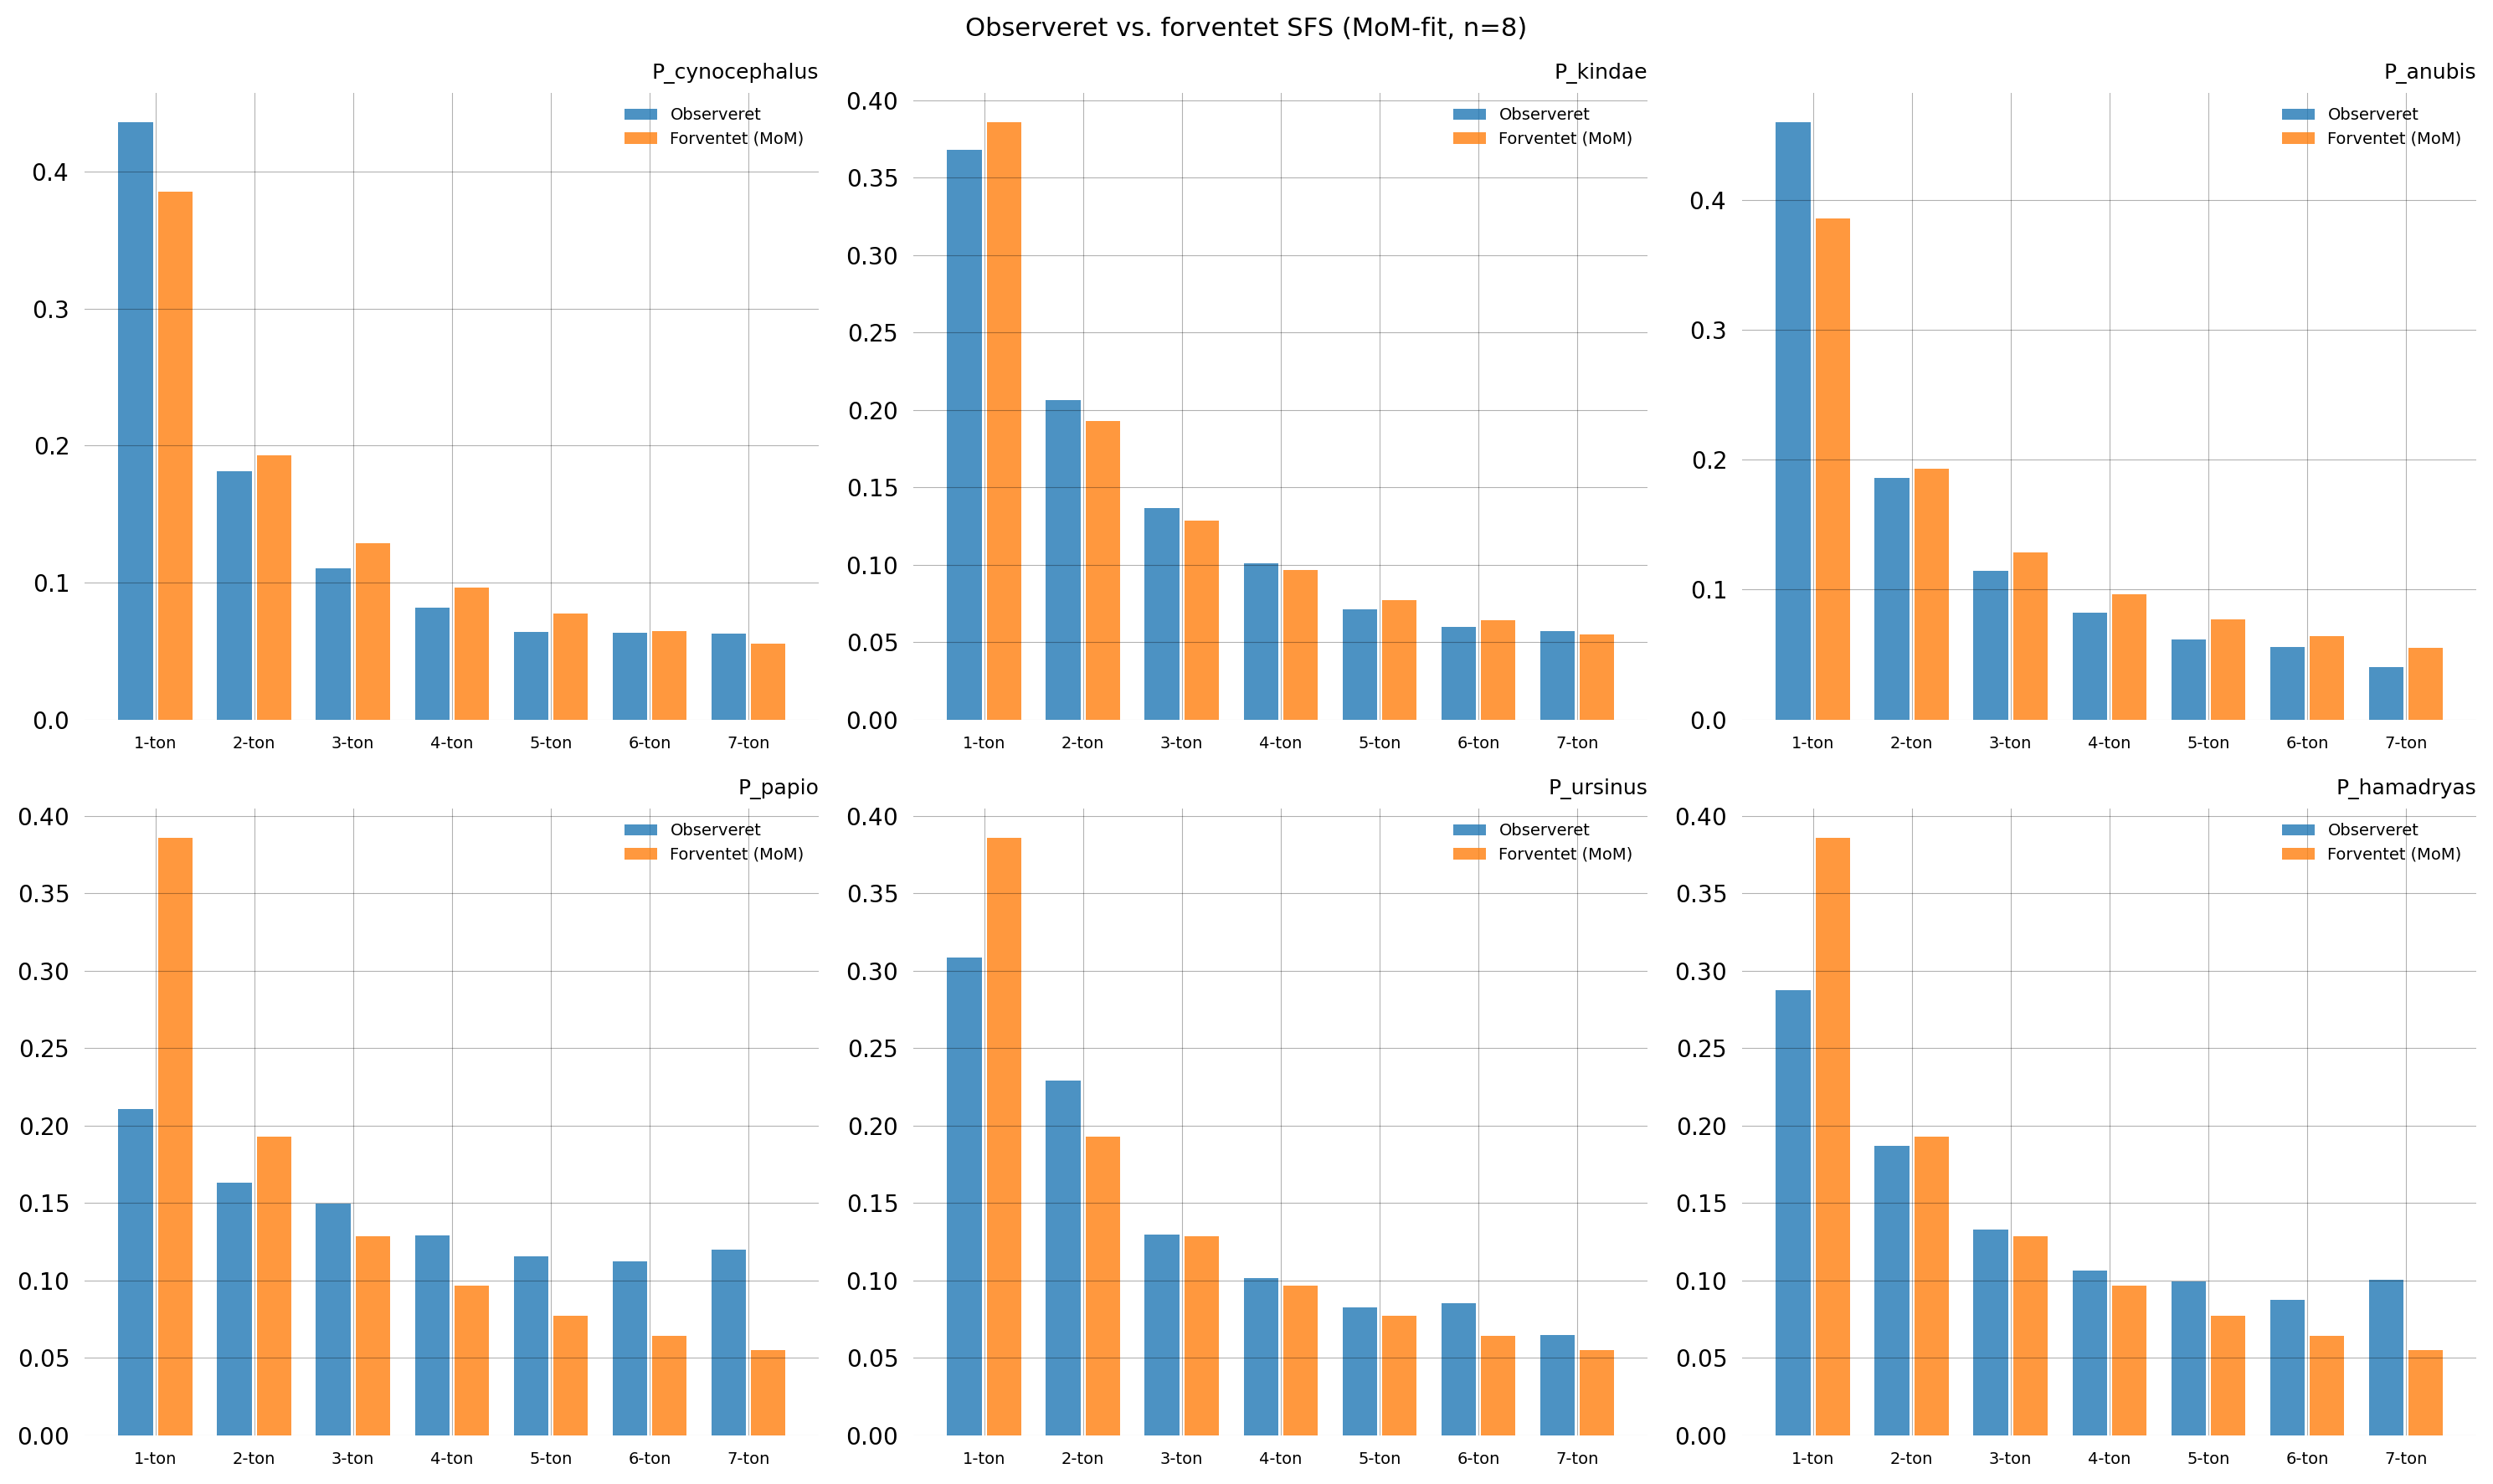

In [31]:
N_SUB = 8

sfs_exp = {}
for name, df in populations.items():
    n_full = int(df['nr_samples'].max())
    # Graf med N_SUB=8
    g = build_coal_graph(N_SUB)
    theta0 = 4 * MU * N_ref_dict[name]
    g.update_weights([theta0])
    data_mom = allele_counts_to_sfs_obs(df, n_sub=N_SUB, n_obs=3000)
    try:
        mom = g.method_of_moments(data_mom)
        th_mom = mom.theta[0]
        Ne_mom = th_mom / (4 * MU) if th_mom > 0 else np.nan
        print(f"{name:<22}: MoM theta={th_mom:.8f}  "
              f"Ne {Ne_mom:,.0f}  residual={mom.residual:.2e}")
    except Exception:
        th_mom = theta0
        Ne_mom = th_mom / (4 * MU) if th_mom > 0 else np.nan
        print(f"{name:<22}: MoM fejlede — "
              f"bruger pi-baseret theta={th_mom:.8f}  Ne~{Ne_mom:,.0f}")
    g.update_weights([th_mom])
    rmat = g.states().T
    exp = [g.expectation(rmat[i]) for i in range(N_SUB - 1)]
    s = sum(exp)
    sfs_exp[name] = [v/s for v in exp] if s > 0 else exp

# Plot
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, name in zip(axes.flat, populations.keys()):
    obs = sfs_unfolded_min[name][:N_SUB - 1]
    exp = sfs_exp[name]
    x      = np.arange(len(exp))
    labels = [f"{i+1}-ton" for i in range(len(exp))]

    ax.bar(x - 0.2, obs[:len(exp)], 0.35,
           label='Observeret',       color='C0', alpha=0.8)
    ax.bar(x + 0.2, exp,             0.35,
           label='Forventet (MoM)',  color='C1', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=7)
    ax.set_title(name, fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle(
    f'Observeret vs. forventet SFS (MoM-fit, n={N_SUB})',
    fontsize=11,
)
plt.tight_layout()
plt.show()

## Msprime-validering

      80,000     0.00288000   11,504,063 [11,156,653 – 11,851,472] 14280.1%

 Ne sand  theta sand  Ne est.  Ne 95 procent lav  Ne 95 procent høj  Bias procent  n_obs
   20000     0.00072  3737195            3573675            3900716       18586.0   3000
   50000     0.00180  8215005            7967384            8462626       16330.0   3000
   80000     0.00288 11504063           11156653           11851472       14280.1   3000


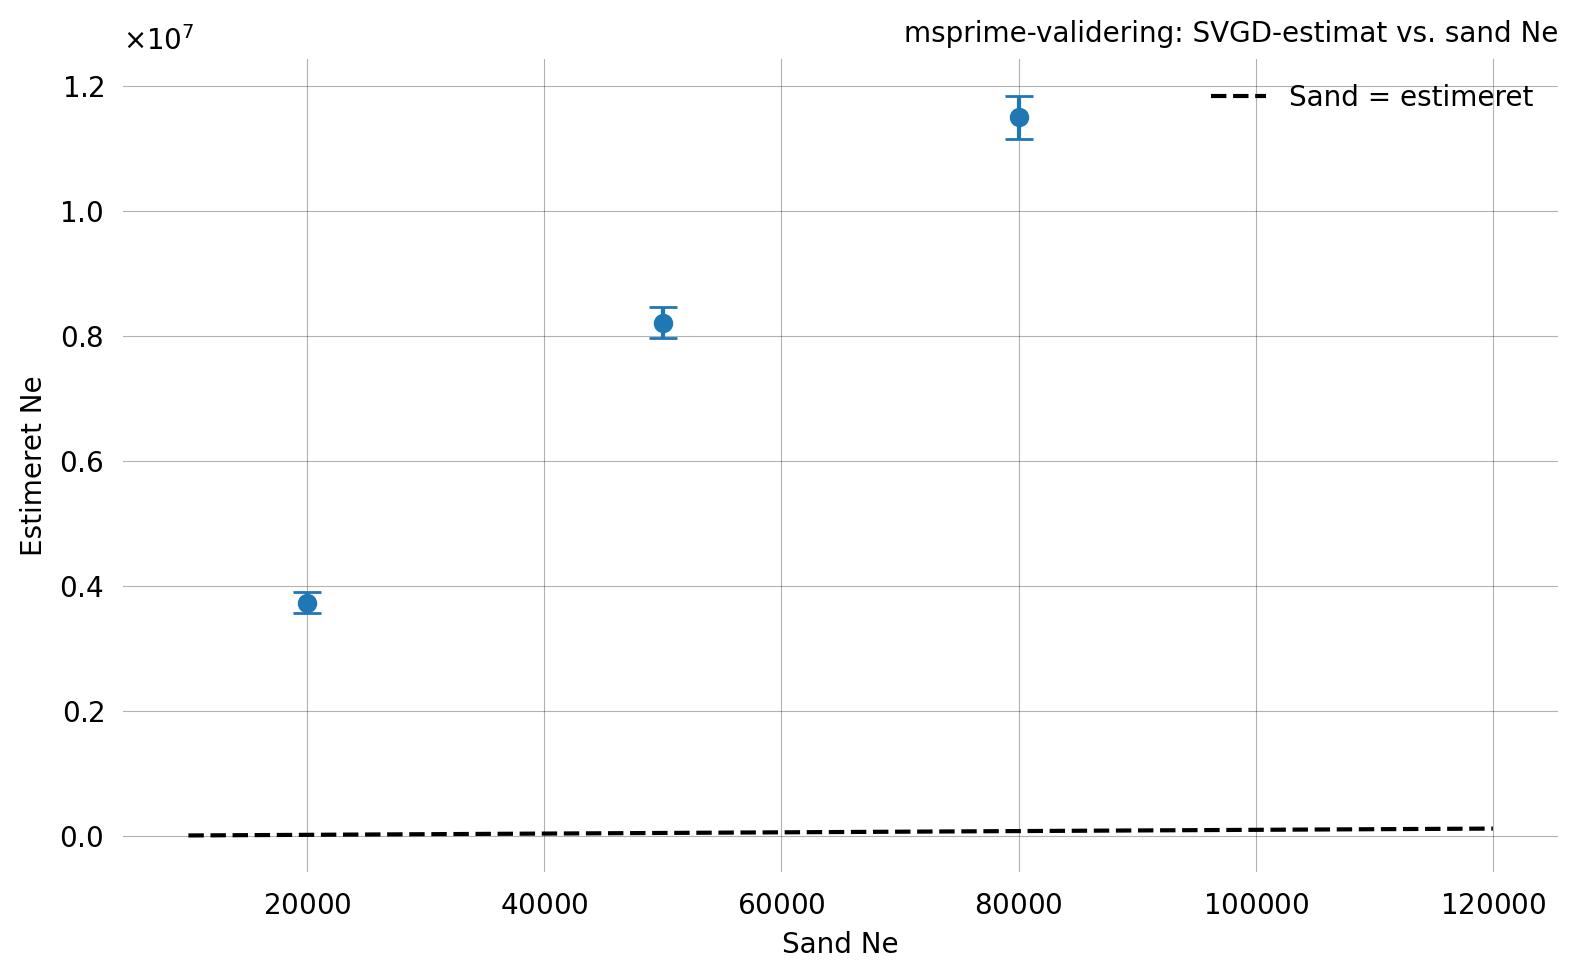

In [9]:
#| label: fig-msprime-validering-bavian
#| fig-cap: "msprime-validering: SVGD finder sande bavian-parametre tilbage."

import msprime

def simulate_bavian_tmrca(Ne, n_loci=5000, n_samples=8):
    obs = []
    ts_list = msprime.sim_ancestry(
        samples=n_samples // 2,
        population_size=Ne,
        num_replicates=n_loci,
        sequence_length=1_000_000,
        recombination_rate=0,
        ploidy=2,
    )
    for ts in ts_list:
        ts_mut = msprime.sim_mutations(ts, rate=MU)
        for var in ts_mut.variants():
            k = int(var.genotypes.sum())
            if 0 < k < n_samples:
                obs.append(float(k))
                break
    return np.array(obs)

# Test tre bavian-realistiske Ne-værdier
Ne_scenarios = [20_000, 50_000, 80_000]

print("msprime-validering: sand Ne -> SVGD-estimat")
print(f"{'Ne (sand)':>12} {'theta (sand)':>14} "
      f"{'Ne (est.)':>12} {'95 procent-CI':>22} {'bias procent':>8}")
print("-" * 75)

ms_rows = []
for Ne_true in Ne_scenarios:
    theta_true = 4 * Ne_true * MU

    # Simuler data
    data_ms = simulate_bavian_tmrca(Ne_true, n_loci=3000, n_samples=8)
    if len(data_ms) < 100:
        print(f"Ne={Ne_true:,}: for få observationer ({len(data_ms)})")
        continue

    # Byg graf og kør SVGD
    g_ms = build_coal_graph(8)
    rewards_ms = g_ms.states().T[:-1]
    g_ms.update_weights([theta_true])

    sparse_ms = dense_to_sparse(
        np.column_stack([
            np.where(data_ms == k+1, data_ms, np.nan)
            for k in range(7)
        ])
    )

    prior_ms = GaussPrior(ci=[theta_true * 0.1, theta_true * 10])

    sv_ms = g_ms.svgd(
        sparse_ms,
        rewards=rewards_ms,
        prior=prior_ms,
        optimizer=Adam(0.1),
        n_particles=60,
        n_iterations=400,
    )

    res_ms  = sv_ms.get_results()
    th_est  = res_ms['theta_mean'].item()
    std_est = res_ms['theta_std'].item()
    Ne_est  = th_est / (4 * MU)
    Ne_low  = (th_est - 1.96 * std_est) / (4 * MU)
    Ne_hi   = (th_est + 1.96 * std_est) / (4 * MU)
    bias_pct = (Ne_est - Ne_true) / Ne_true * 100

    print(f"{Ne_true:>12,} {theta_true:>14.8f} "
          f"{Ne_est:>12,.0f} "
          f"[{Ne_low:>9,.0f} – {Ne_hi:>9,.0f}] "
          f"{bias_pct:>7.1f}%")

    ms_rows.append({
        'Ne sand':    Ne_true,
        'theta sand': round(theta_true, 8),
        'Ne est.':    round(Ne_est),
        'Ne 95 procent lav': round(Ne_low),
        'Ne 95 procent høj': round(Ne_hi),
        'Bias procent':     round(bias_pct, 1),
        'n_obs':      len(data_ms),
    })

df_ms = pd.DataFrame(ms_rows)
print()
print(df_ms.to_string(index=False))

# Plot: sand vs. estimeret Ne
fig, ax = plt.subplots(figsize=(8, 5))
for _, row in df_ms.iterrows():
    ax.errorbar(
        row['Ne sand'], row['Ne est.'],
        yerr=[[row['Ne est.'] - row['Ne 95 procent lav']],
              [row['Ne 95 procent høj'] - row['Ne est.']]],
        fmt='o', capsize=5, color='C0',
    )
ne_range = [df_ms['Ne sand'].min() * 0.5, df_ms['Ne sand'].max() * 1.5]
ax.plot(ne_range, ne_range, 'k--', label='Sand = estimeret')
ax.set_xlabel('Sand Ne'); ax.set_ylabel('Estimeret Ne')
ax.set_title('msprime-validering: SVGD-estimat vs. sand Ne')
ax.legend(); plt.tight_layout(); plt.show()

## Gem resultater til NB07B

In [34]:
from pathlib import Path

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

# Population summary
rows = []
for name, df in populations.items():
    r = svgd_results[name]
    rows.append({
        'population':  name,
        'n_haplotypes': r['n_hap'],
        'pi':           nucleotide_diversity(df),
        'theta_W':      watterson_theta(df),
        'N_ref':        N_ref_dict[name],
        'tajimas_d':    tajimas_d(df),
        'theta_mean':   r['theta'],
        'theta_std':    r['std'],
        'Ne_svgd':      r['Ne'],
    })
pd.DataFrame(rows).to_csv(
    RESULTS_DIR / "population_summary.csv", index=False)

# SFS
pd.DataFrame([
    {'population': n,
     **{f'b{i+1}': v for i, v in enumerate(sfs_unfolded_min[n])}}
    for n in populations
]).to_csv(RESULTS_DIR / "sfs_unfolded.csv", index=False)

pd.DataFrame([
    {'population': n,
     **{f'b{i+1}': v for i, v in enumerate(sfs_folded_full[n])}}
    for n in populations
]).to_csv(RESULTS_DIR / "sfs_folded.csv", index=False)

# Ne reference
pd.DataFrame([
    {'population': n, 'N_ref': v}
    for n, v in N_ref_dict.items()
]).to_csv(RESULTS_DIR / "N_ref.csv", index=False)

# SVGD-resultater — inkl. Ne_low og Ne_hi til NB07B
pd.DataFrame([
    {
        'population':   n,
        'theta_mean':   r['theta'],
        'theta_std':    r['std'],
        'Ne':           r['Ne'],
        'Ne_low':       r.get('Ne_low', np.nan),
        'Ne_hi':        r.get('Ne_hi',  np.nan),
        'E_H_yr':       r.get('E_H_yr', np.nan),
        'n_haplotypes': r['n_hap'],
    }
    for n, r in svgd_results.items()
]).to_csv(RESULTS_DIR / "svgd_results.csv", index=False)

# SNP-filer per population
for name, df in populations.items():
    safe     = name.replace('. ', '_').replace('.', '').replace(' ', '_')
    filepath = RESULTS_DIR / f"snp_{safe}.csv"
    df.to_csv(filepath, index=False)

# Verifikation
print("Gemte filer:")
expected = [
    "population_summary.csv",
    "sfs_unfolded.csv",
    "sfs_folded.csv",
    "N_ref.csv",
    "svgd_results.csv",
] + [
    f"snp_{n.replace('. ', '_').replace('.', '').replace(' ', '_')}.csv"
    for n in populations
]

all_ok = True
for fname in expected:
    p = RESULTS_DIR / fname
    if p.exists():
        print(f" {p.name:<45} {p.stat().st_size/1024:.1f} KB")
    else:
        print(f" MANGLER: {fname}")
        all_ok = False

print()
if all_ok:
    print(f"Alle {len(expected)} filer gemt korrekt")
else:
    print("ADVARSEL: Nogle filer mangler — tjek ovenstående")

# Verificer at NB07B kan indlæse svgd_results korrekt
df_check = pd.read_csv(RESULTS_DIR / "svgd_results.csv")
print(f"\nsvgd_results.csv kolonner: {list(df_check.columns)}")
print(df_check[['population', 'Ne', 'Ne_low', 'Ne_hi']].to_string(index=False))

Gemte filer:
 population_summary.csv                        1.0 KB
 sfs_unfolded.csv                              0.4 KB
 sfs_folded.csv                                2.1 KB
 N_ref.csv                                     0.2 KB
 svgd_results.csv                              0.8 KB
 snp_P_cynocephalus.csv                        20590.0 KB
 snp_P_kindae.csv                              11585.8 KB
 snp_P_anubis.csv                              16360.8 KB
 snp_P_papio.csv                               1539.7 KB
 snp_P_ursinus.csv                             5049.2 KB
 snp_P_hamadryas.csv                           6451.3 KB

Alle 11 filer gemt korrekt

svgd_results.csv kolonner: ['population', 'theta_mean', 'theta_std', 'Ne', 'Ne_low', 'Ne_hi', 'E_H_yr', 'n_haplotypes']
    population           Ne       Ne_low        Ne_hi
P_cynocephalus 2.142605e+07 2.052612e+07 2.232597e+07
      P_kindae 1.973532e+07 1.895190e+07 2.051874e+07
      P_anubis 2.348861e+07 2.252769e+07 2.444953e+07
       